# SWH-TRRC-011 — Peta Overlay & Analisis Terrain

Notebook ini **sengaja belum menghitung kebutuhan air apa pun**. Ruang lingkupnya dua hal:

1. **Overlay peta** — menampilkan batas lahan `SWH-TRRC-011.kml` di atas citra satelit,
   supaya bentuk, ukuran, dan letak lahan terlihat apa adanya sebelum dijadikan angka.
2. **Analisis terrain** — ketinggian, kemiringan, arah hadap, dan arah aliran air permukaan.

Semua hitungan irigasi (ETo, Kc, perkolasi, debit, water loss, neraca air) **ditunda**
ke notebook berikutnya. Alasannya bukan sekadar urutan kerja: hasil bagian 6 di bawah
menunjukkan lahan ini **berlereng**, dan lahan berlereng tidak boleh diperlakukan
seperti sawah datar. Bentuk petak, arah aliran, dan tinggi terjun harus jelas dulu.

### Sumber data

| Apa | Dari mana | Catatan |
|---|---|---|
| Batas lahan | `SWH-TRRC-011.kml` | 1 poligon, 197 simpul — dibaca apa adanya |
| Citra satelit | Esri World Imagery (Maxar, Earthstar) | hanya latar peta, tidak dipakai menghitung |
| Model elevasi (DEM) | Terrarium — AWS `elevation-tiles-prod` | turunan SRTM/ASTER, **bukan** survei lapangan |
| Cek silang elevasi | OpenTopoData (`srtm30m`, `aster30m`, `srtm90m`) | untuk mengukur ketidakpastian tegak |

### Yang perlu diketahui sebelum membaca hasilnya

> **KML ini tidak memuat data ketinggian.** Semua 197 simpul poligon bernilai
> `altitude = 0` (mode *clamp to ground* Google Earth). Jadi terrain **tidak bisa**
> dibaca dari KML — harus diambil dari DEM luar. Ini diverifikasi di bagian 1.
>
> **DEM global ≠ survei topografi.** Resolusi efektifnya ~30 m, sedangkan lahan ini
> hanya ~260 m. Artinya lahan hanya terwakili beberapa piksel sumber. Angka arah dan
> besaran lereng **umum** bisa dipercaya; detail per petak, galengan, dan teras
> **tidak**. Ketidakpastian tegaknya diukur di bagian 5b, dan seluruh batasan
> dirangkum di bagian 12.

## 0. Persiapan

In [1]:
import math, re, json, io as _io, socket, heapq, urllib.request, urllib.error
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.colors import LightSource, BoundaryNorm, ListedColormap
from PIL import Image

pd.set_option("display.width", 150); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

# ============================ KONFIGURASI ============================
NAMA_KML     = "SWH-TRRC-011.kml"
ZOOM_KONTEKS = 16       # citra: peta ikhtisar
ZOOM_DETAIL  = 19       # citra: peta rinci (turun ke 18 kalau tile tidak ada)
ZOOM_DEM     = 15       # DEM terrarium (zoom maksimum yang disediakan)
MARGIN_PETA  = 40.0     # m - ruang kosong di sekeliling lahan pada peta detail
MARGIN_DEM   = 250.0    # m - DEM diambil lebih luas dari lahan supaya tepi tidak bias
BEDA_KONTUR  = 2.0      # m - selang garis kontur
MAX_TILE     = 64
# =====================================================================

ROOT     = Path.cwd().parent if Path.cwd().name == "note" else Path.cwd()
KML      = ROOT / NAMA_KML
OUT_DIR  = ROOT / "note" / "output-swh-trrc"; OUT_DIR.mkdir(parents=True, exist_ok=True)
GBR_DIR  = OUT_DIR / "gambar";               GBR_DIR.mkdir(parents=True, exist_ok=True)
TILE_DIR = ROOT / "note" / "output" / "tiles";     TILE_DIR.mkdir(parents=True, exist_ok=True)
DEM_DIR  = ROOT / "note" / "output" / "tiles-dem"; DEM_DIR.mkdir(parents=True, exist_ok=True)

DPI_GAMBAR = 150
GAMBAR_TERSIMPAN = []

def simpan_gambar(fig, nama, dpi=None):
    """Simpan satu figure (beserta semua subplot-nya) ke output-swh-trrc/gambar/*.png."""
    berkas = GBR_DIR / f"{nama}.png"
    fig.savefig(berkas, dpi=DPI_GAMBAR if dpi is None else dpi,
                bbox_inches="tight", facecolor="white")
    GAMBAR_TERSIMPAN.append(berkas)
    print(f"[gambar] {berkas.name:<32} {berkas.stat().st_size/1024:>7,.0f} KB")
    return berkas

assert KML.exists(), f"KML tidak ditemukan: {KML}"
print("kml    :", KML.name, f"({KML.stat().st_size:,} byte)")
print("output :", OUT_DIR)
print("gambar :", GBR_DIR)
print("tile   :", TILE_DIR, "|", DEM_DIR)

kml    : SWH-TRRC-011.kml (10,714 byte)
output : d:\WMS_AgrinIrigation\note\output-swh-trrc
gambar : d:\WMS_AgrinIrigation\note\output-swh-trrc\gambar
tile   : d:\WMS_AgrinIrigation\note\output\tiles | d:\WMS_AgrinIrigation\note\output\tiles-dem


---
## 1. Apa saja isi file KML ini?

Dibaca dulu apa adanya — semua `Placemark`, semua tipe geometri — sebelum ada asumsi.
Yang diperiksa ada tiga:

1. **Ada berapa poligon?** Menentukan apakah lahan ini satu hamparan atau sudah dibagi petak.
2. **Nilai `altitude` tiap simpul.** Kalau semuanya `0`, KML memakai mode *clamp to ground*
   dan terrain **tidak ada** di dalam file — harus diambil dari DEM luar.
3. **Geometri selain poligon.** `Point`/`LineString` sering menandai bangunan atau saluran,
   dan tidak boleh ikut terhitung sebagai lahan.

In [2]:
raw = KML.read_text(encoding="utf-8")

def ambil_koordinat(blok):
    """Teks <coordinates> -> daftar (lon, lat, alt). alt = None kalau tidak ditulis."""
    out = []
    for tok in blok.split():
        bag = tok.split(",")
        if len(bag) >= 2:
            out.append((float(bag[0]), float(bag[1]),
                        float(bag[2]) if len(bag) >= 3 else None))
    return out

def luas_derajat(titik):
    """Luas kasar (derajat^2) - hanya untuk mengurutkan besar-kecil."""
    x = np.array([p[0] for p in titik]); y = np.array([p[1] for p in titik])
    return 0.5*abs(np.dot(x, np.roll(y, -1)) - np.dot(np.roll(x, -1), y))

geometri = []
for m in re.finditer(r"<Placemark[^>]*>(.*?)</Placemark>", raw, re.S):
    body = m.group(1)
    nm   = re.search(r"<name>(.*?)</name>", body, re.S)
    nama = nm.group(1).strip() if nm else "(tanpa nama)"
    luar = re.findall(r"<outerBoundaryIs>\s*<LinearRing>.*?<coordinates>(.*?)</coordinates>",
                      body, re.S)
    dalam = re.findall(r"<innerBoundaryIs>\s*<LinearRing>.*?<coordinates>(.*?)</coordinates>",
                       body, re.S)
    if luar:
        for cd in luar:
            geometri.append({"nama": nama, "tipe": "Polygon",
                             "titik": ambil_koordinat(cd), "lubang": len(dalam)})
    else:
        for tipe in ("LineString", "Point"):
            for g in re.finditer(rf"<{tipe}>(.*?)</{tipe}>", body, re.S):
                for cd in re.finditer(r"<coordinates>(.*?)</coordinates>", g.group(1), re.S):
                    geometri.append({"nama": nama, "tipe": tipe,
                                     "titik": ambil_koordinat(cd.group(1)), "lubang": 0})

nama_dok = re.findall(r"<Document[^>]*>\s*<name>(.*?)</name>", raw, re.S)
print(f"Nama dokumen     : {nama_dok[0] if nama_dok else '(tidak ada)'}")
print(f"Jumlah Placemark : {len(re.findall(r'<Placemark', raw))}")
print(f"Jumlah geometri  : {len(geometri)}\n")

for g in geometri:
    alt = [t[2] for t in g["titik"] if t[2] is not None]
    ket = (f"alt {min(alt):.1f}..{max(alt):.1f} m" if alt else "alt tidak ditulis")
    print(f"  {g['tipe']:<11} | {g['nama']:<20} | {len(g['titik']):>3} simpul | "
          f"{g['lubang']} lubang | {ket}")

# -------- poligon lahan --------
kandidat = [g for g in geometri if g["tipe"] == "Polygon" and len(g["titik"]) >= 4]
assert kandidat, "tidak ada poligon di dalam KML ini"
batas    = max(kandidat, key=lambda g: luas_derajat(g["titik"]))
petak_kml = [g for g in kandidat if g is not batas]

# -------- periksa altitude --------
alt_batas = [t[2] for t in batas["titik"] if t[2] is not None]
KML_PUNYA_TINGGI = bool(alt_batas) and (max(alt_batas) - min(alt_batas)) > 0.5

print("\n" + "=" * 72)
print(f"  Poligon    : {len(kandidat)}  ->  1 batas lahan ('{batas['nama']}')"
      f" + {len(petak_kml)} poligon petak")
if not petak_kml:
    print("               Lahan ini BELUM dibagi petak di dalam KML.")
if alt_batas:
    print(f"  Altitude   : {min(alt_batas):.2f} .. {max(alt_batas):.2f} m "
          f"(rentang {max(alt_batas)-min(alt_batas):.2f} m)")
print(f"  Terrain di dalam KML : {'ADA' if KML_PUNYA_TINGGI else 'TIDAK ADA'}")
if not KML_PUNYA_TINGGI:
    print("     -> semua simpul rata di 0 m (clamp to ground Google Earth).")
    print("     -> ketinggian WAJIB diambil dari DEM luar (bagian 5).")
print("=" * 72)

Nama dokumen     : SWH-012
Jumlah Placemark : 2
Jumlah geometri  : 2

  Point       | Untitled placemark   |   1 simpul | 0 lubang | alt 603.3..603.3 m
  Polygon     | SWH-TRRC-01          | 197 simpul | 0 lubang | alt 0.0..0.0 m

  Poligon    : 1  ->  1 batas lahan ('SWH-TRRC-01') + 0 poligon petak
               Lahan ini BELUM dibagi petak di dalam KML.
  Altitude   : 0.00 .. 0.00 m (rentang 0.00 m)
  Terrain di dalam KML : TIDAK ADA
     -> semua simpul rata di 0 m (clamp to ground Google Earth).
     -> ketinggian WAJIB diambil dari DEM luar (bagian 5).


---
## 2. Dari derajat ke meter, lalu ukuran lahan

Koordinat KML satuannya **derajat**, dan 1 derajat bujur di garis lintang ini tidak sama
panjang dengan 1 derajat lintang. Jadi semua titik dipindah dulu ke **meter lokal**
dengan satu titik acuan yang sama — acuan ini dipakai konsisten sampai akhir notebook,
termasuk untuk citra dan DEM.

Yang dihitung di sini hanya **ukuran geometris** (luas, keliling, kotak pembatas).
Belum ada hitungan air sama sekali.

In [3]:
ring_ll = [(t[0], t[1]) for t in batas["titik"]]
if (abs(ring_ll[0][0]-ring_ll[-1][0]) < 1e-12 and abs(ring_ll[0][1]-ring_ll[-1][1]) < 1e-12):
    ring_ll = ring_ll[:-1]
    print("Cincin batas sudah tertutup rapi (simpul penutup dibuang).")
else:
    d = math.hypot(ring_ll[0][0]-ring_ll[-1][0], ring_ll[0][1]-ring_ll[-1][1]) * 111_000
    print(f"CATATAN: cincin tidak persis tertutup, celah ~{d:.2f} m -> ditutup otomatis.")

lon = np.array([p[0] for p in ring_ll]); lat = np.array([p[1] for p in ring_ll])
lat0, lon0 = float(lat.mean()), float(lon.mean())
phi = math.radians(lat0)
M_PER_DEG_LAT = 111_132.92 - 559.82*math.cos(2*phi) + 1.175*math.cos(4*phi)
M_PER_DEG_LON = 111_412.84*math.cos(phi) - 93.5*math.cos(3*phi)

def ke_meter(titik):
    """(lon, lat) derajat -> (x, y) meter, acuan sama untuk semua geometri."""
    return [((lo - lon0)*M_PER_DEG_LON, (la - lat0)*M_PER_DEG_LAT) for lo, la in titik]

def ke_derajat(x, y):
    """(x, y) meter -> (lon, lat) derajat. Kebalikan ke_meter()."""
    return (np.asarray(x)/M_PER_DEG_LON + lon0, np.asarray(y)/M_PER_DEG_LAT + lat0)

X = (lon - lon0) * M_PER_DEG_LON
Y = (lat - lat0) * M_PER_DEG_LAT
RING = list(zip(X, Y))
Xc, Yc = np.append(X, X[0]), np.append(Y, Y[0])

def luas_shoelace(poly):
    if len(poly) < 3:
        return 0.0
    x = np.array([p[0] for p in poly], float); y = np.array([p[1] for p in poly], float)
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(np.roll(x, -1), y))

def pusat_poligon(poly):
    x = np.array([q[0] for q in poly], float); y = np.array([q[1] for q in poly], float)
    x2, y2 = np.roll(x, -1), np.roll(y, -1)
    cr = x*y2 - x2*y; A = cr.sum()/2.0
    if abs(A) < 1e-9:
        return float(x.mean()), float(y.mean())
    return float(((x+x2)*cr).sum()/(6*A)), float(((y+y2)*cr).sum()/(6*A))

def luas_geodesik(lon_deg, lat_deg):
    """Luas di permukaan bola (m2) - cek silang untuk proyeksi lokal."""
    R = 6_371_008.8
    la = np.radians(np.asarray(lon_deg, float)); ph = np.radians(np.asarray(lat_deg, float))
    la2, ph2 = np.roll(la, -1), np.roll(ph, -1)
    return abs(np.sum((la2-la)*(2+np.sin(ph)+np.sin(ph2))) * R*R / 2.0)

LUAS_M2  = luas_shoelace(RING)
LUAS_HA  = LUAS_M2 / 10_000.0
KELILING = float(np.hypot(np.diff(Xc), np.diff(Yc)).sum())
LUAS_GEO = luas_geodesik(lon, lat)
CX, CY   = pusat_poligon(RING)

print("\n" + "=" * 60)
print(f"        UKURAN LAHAN {batas['nama']}  (datar / peta)")
print("=" * 60)
print(f"  Luas            : {LUAS_M2:>12,.1f} m2  =  {LUAS_HA:.4f} ha")
print(f"  Keliling        : {KELILING:>12,.1f} m")
print(f"  Kotak pembatas  : {X.max()-X.min():>7.0f} m (T-B) x {Y.max()-Y.min():.0f} m (U-S)")
print(f"  Titik tengah    : {lat0:.6f} LS, {lon0:.6f} BT")
print("-" * 60)
print(f"  Cek silang geodesik : {LUAS_GEO:,.1f} m2 "
      f"-> selisih {100*abs(LUAS_GEO-LUAS_M2)/LUAS_GEO:.3f} %")
print(f"  1 deg lintang = {M_PER_DEG_LAT:,.1f} m | 1 deg bujur = {M_PER_DEG_LON:,.1f} m")
print("=" * 60)
print("\nCATATAN: luas ini luas DATAR (proyeksi peta). Pada lahan berlereng, luas")
print("permukaan sebenarnya lebih besar - selisihnya dihitung di bagian 7.")

# titik penanda non-poligon (kalau ada) - ditampilkan, tidak dihitung sebagai lahan
penanda = [g for g in geometri if g["tipe"] == "Point"]
for g in penanda:
    lo, la, al = g["titik"][0]
    px, py = ke_meter([(lo, la)])[0]
    print(f"\nPenanda '{g['nama']}': {la:.6f}, {lo:.6f}"
          f"  (alt KML {al:.1f} m) -> x={px:+.0f} m, y={py:+.0f} m dari titik tengah")

Cincin batas sudah tertutup rapi (simpul penutup dibuang).

        UKURAN LAHAN SWH-TRRC-01  (datar / peta)
  Luas            :     33,163.0 m2  =  3.3163 ha
  Keliling        :        818.6 m
  Kotak pembatas  :     260 m (T-B) x 257 m (U-S)
  Titik tengah    : -8.371211 LS, 115.137653 BT
------------------------------------------------------------
  Cek silang geodesik : 33,302.5 m2 -> selisih 0.419 %
  1 deg lintang = 110,597.8 m | 1 deg bujur = 110,141.1 m

CATATAN: luas ini luas DATAR (proyeksi peta). Pada lahan berlereng, luas
permukaan sebenarnya lebih besar - selisihnya dihitung di bagian 7.

Penanda 'Untitled placemark': -8.371547, 115.138168  (alt KML 603.3 m) -> x=+57 m, y=-37 m dari titik tengah


---
## 3. Peta dasar dari citra satelit

Citra diambil sebagai *tile* Esri World Imagery dan disusun jadi satu gambar, lalu
dipasang pada sumbu **meter lokal** yang sama dengan poligon — supaya batas KML dan
citra benar-benar bertumpuk, bukan sekadar berdampingan.

Tile disimpan ke `note/output/tiles/`, jadi hanya diunduh sekali. Kalau jaringan mati,
peta tetap digambar tanpa citra.

> **Zoom tertinggi belum tentu ada citranya.** Untuk zoom yang belum diliput, Esri
> tidak mengembalikan error — melainkan **HTTP 200 berisi pelat abu-abu**
> *"Map data not yet available"*. Kalau hanya mengandalkan `try/except`, pelat itu akan
> lolos dan terpasang sebagai "peta". Karena itu isi tiap tile diperiksa: pelat kosong
> praktis tanpa warna dan tanpa variasi. Kalau kedapatan kosong, zoom diturunkan satu
> tingkat dan pelat tersebut **tidak** ikut disimpan ke cache.

In [4]:
TILE_URL = ("https://server.arcgisonline.com/ArcGIS/rest/services/"
            "World_Imagery/MapServer/tile/{z}/{y}/{x}")
KREDIT   = "Citra: Esri, Maxar, Earthstar Geographics"
UA       = {"User-Agent": "WMS-AgrinIrigation/1.0 (notebook riset lokal)"}

def lonlat_ke_piksel(lo, la, z):
    n = 256 * 2**z
    return ((lo+180.0)/360.0*n,
            (1.0 - math.log(math.tan(math.radians(la)) +
                            1.0/math.cos(math.radians(la)))/math.pi)/2.0*n)

def piksel_ke_lonlat(px, py, z):
    n = 256 * 2**z
    return (px/n*360.0 - 180.0,
            math.degrees(math.atan(math.sinh(math.pi*(1.0 - 2.0*py/n)))))

def meter_per_piksel(z):
    return 40_075_016.686 * math.cos(phi) / 2**z / 256

class TileKosong(RuntimeError):
    """Tile terunduh tapi isinya pelat 'Map data not yet available'."""

def tile_kosong(img):
    """Kenali pelat kosong Esri.

    Untuk zoom yang belum punya citra, server membalas HTTP 200 berisi pelat abu-abu
    bertuliskan 'Map data not yet available' - BUKAN error. Jadi kegagalan ini tidak
    akan pernah muncul sebagai exception dan harus dikenali dari isi gambarnya:
    pelat itu praktis tanpa warna (R=G=B) dan nyaris tanpa variasi.
    """
    a = img.astype(np.int16)
    tanpa_warna = ((a.max(axis=2) - a.min(axis=2)) < 8).mean()
    return tanpa_warna > 0.90 and a.std() < 12

def ambil_tile(z, x, y, timeout=25):
    f = TILE_DIR / f"{z}_{x}_{y}.jpg"
    if f.exists():
        img = np.asarray(Image.open(f).convert("RGB"))
        if tile_kosong(img):
            f.unlink()                      # buang pelat kosong yang terlanjur tersimpan
            raise TileKosong(f"z{z} belum punya citra di lokasi ini")
        return img
    with urllib.request.urlopen(urllib.request.Request(TILE_URL.format(z=z, x=x, y=y),
                                                       headers=UA), timeout=timeout) as r:
        d = r.read()
    img = np.asarray(Image.open(_io.BytesIO(d)).convert("RGB"))
    if tile_kosong(img):
        raise TileKosong(f"z{z} belum punya citra di lokasi ini")
    f.write_bytes(d)                        # hanya tile berisi citra yang dicache
    return img

def susun_basemap(z, margin_m):
    """Susun citra yang menutupi lahan + margin. -> (kanvas, extent meter, n_tile)."""
    dlo = margin_m / M_PER_DEG_LON; dla = margin_m / M_PER_DEG_LAT
    px0, py0 = lonlat_ke_piksel(lon.min()-dlo, lat.max()+dla, z)
    px1, py1 = lonlat_ke_piksel(lon.max()+dlo, lat.min()-dla, z)
    tx0, ty0, tx1, ty1 = int(px0//256), int(py0//256), int(px1//256), int(py1//256)
    n_tile = (tx1-tx0+1)*(ty1-ty0+1)
    if n_tile > MAX_TILE:
        raise RuntimeError(f"butuh {n_tile} tile (batas {MAX_TILE})")
    kanvas = np.zeros(((ty1-ty0+1)*256, (tx1-tx0+1)*256, 3), dtype=np.uint8)
    for ty in range(ty0, ty1+1):
        for tx in range(tx0, tx1+1):
            kanvas[(ty-ty0)*256:(ty-ty0+1)*256,
                   (tx-tx0)*256:(tx-tx0+1)*256] = ambil_tile(z, tx, ty)[:, :, :3]
    lk, la_ = piksel_ke_lonlat(tx0*256, ty0*256, z)
    lka, lb = piksel_ke_lonlat((tx1+1)*256, (ty1+1)*256, z)
    return kanvas, [(lk-lon0)*M_PER_DEG_LON, (lka-lon0)*M_PER_DEG_LON,
                    (lb-lat0)*M_PER_DEG_LAT, (la_-lat0)*M_PER_DEG_LAT], n_tile

socket.setdefaulttimeout(30)
CITRA = {}
for label, z, mg in (("konteks", ZOOM_KONTEKS, 700.0), ("detail", ZOOM_DETAIL, MARGIN_PETA)):
    for zz in (z, z-1, z-2):            # turun zoom kalau tile belum tersedia
        try:
            img, ext, n = susun_basemap(zz, mg)
            CITRA[label] = {"img": img, "extent": ext, "zoom": zz, "n_tile": n}
            print(f"[{label:<8}] z{zz} | {img.shape[1]}x{img.shape[0]} px dari {n} tile "
                  f"| {meter_per_piksel(zz):.2f} m/piksel")
            break
        except Exception as e:
            print(f"[{label:<8}] z{zz} gagal ({type(e).__name__}: {e}) - coba zoom lebih rendah")
    else:
        CITRA[label] = None
        print(f"[{label:<8}] citra tidak tersedia - peta digambar tanpa latar")

ADA_CITRA = CITRA.get("detail") is not None
print("\n" + (KREDIT if ADA_CITRA else "(tanpa citra satelit)"))

[konteks ] z16 | 1024x768 px dari 12 tile | 2.36 m/piksel
[detail  ] z19 gagal (TileKosong: z19 belum punya citra di lokasi ini) - coba zoom lebih rendah
[detail  ] z18 | 768x768 px dari 9 tile | 0.59 m/piksel

Citra: Esri, Maxar, Earthstar Geographics


---
## 4. Overlay: batas lahan di atas citra

Inilah keluaran pertama yang diminta — **lihat dulu, hitung belakangan**.

Dua panel: kiri **konteks** (di mana lahan ini berada terhadap sekitarnya), kanan
**rinci** (bentuk batas dan apa yang tampak di dalamnya). Batas KML digambar kuning,
titik penanda ditandai, disertai batang skala dan panah utara.

[gambar] 01_overlay_citra.png               2,886 KB


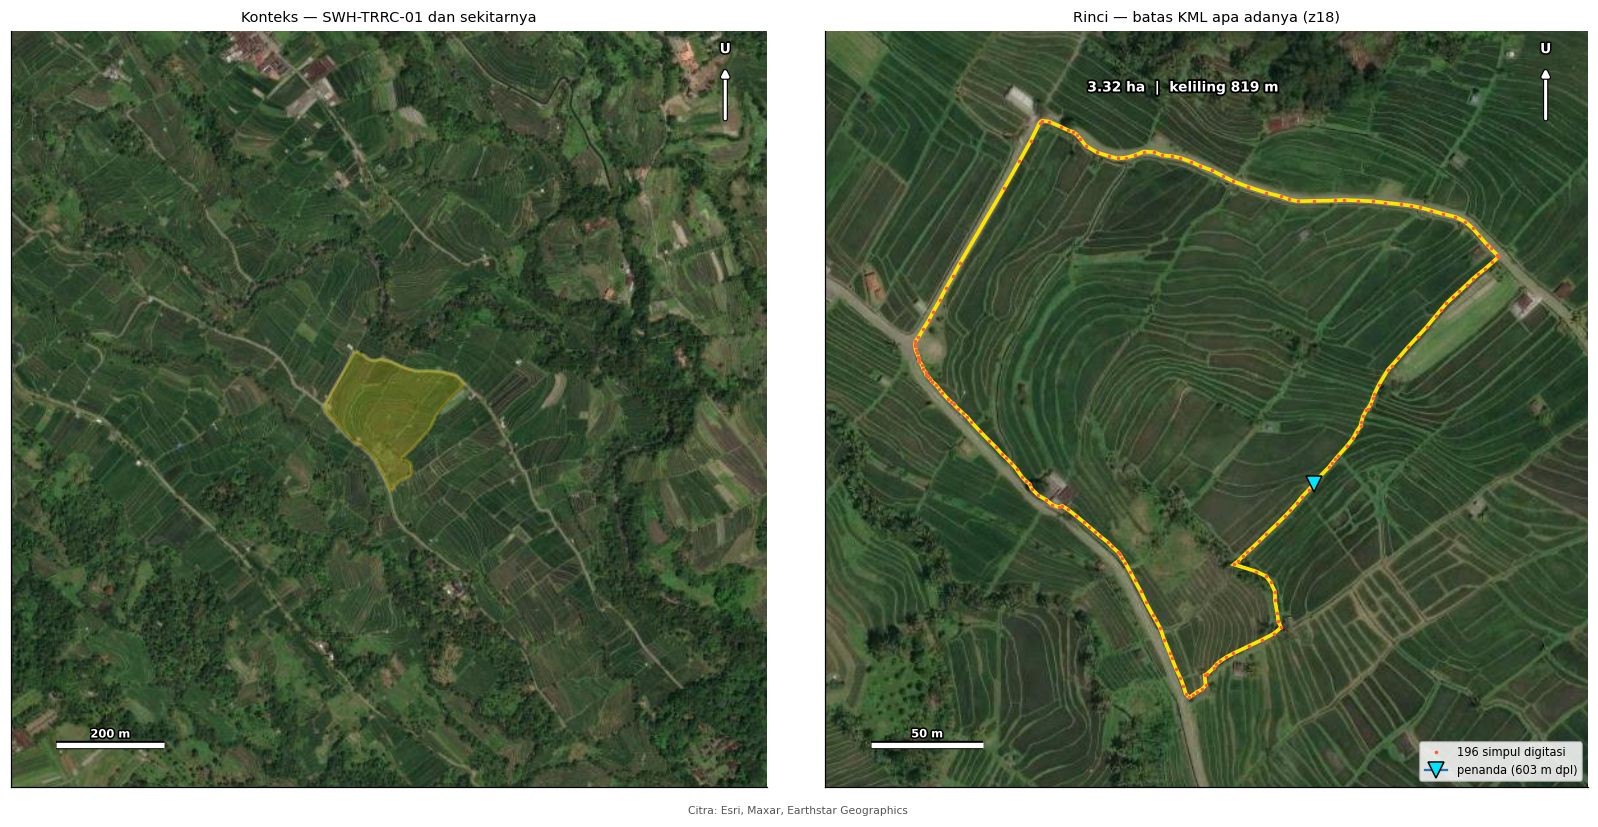

In [5]:
def batang_skala(ax, x0, y0, panjang_m, warna="white"):
    ax.plot([x0, x0+panjang_m], [y0, y0], color=warna, lw=3.5, solid_capstyle="butt",
            path_effects=[pe.withStroke(linewidth=5.5, foreground="black")], zorder=9)
    ax.text(x0+panjang_m/2, y0+panjang_m*0.045, f"{panjang_m:.0f} m", ha="center",
            va="bottom", fontsize=7.5, color=warna, weight="bold", zorder=9,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])

def panah_utara(ax, frac_x=0.945, frac_y=0.88, panjang=0.075):
    ax.annotate("", xy=(frac_x, frac_y+panjang), xytext=(frac_x, frac_y),
                xycoords="axes fraction", zorder=9,
                arrowprops=dict(arrowstyle="-|>", color="white", lw=2,
                                path_effects=[pe.withStroke(linewidth=3.5,
                                                            foreground="black")]))
    ax.text(frac_x, frac_y+panjang+0.012, "U", transform=ax.transAxes, ha="center",
            va="bottom", fontsize=9, color="white", weight="bold", zorder=9,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])

def pasang_citra(ax, label):
    c = CITRA.get(label)
    if c is not None:
        ax.imshow(c["img"], extent=c["extent"], origin="upper",
                  interpolation="bilinear", zorder=0)
    else:
        ax.set_facecolor("#e8e8e8")
    return c

def rapikan(ax, judul, xlim, ylim, skala):
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_aspect("equal"); ax.set_title(judul, fontsize=9.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    batang_skala(ax, xlim[0] + 0.06*(xlim[1]-xlim[0]),
                 ylim[0] + 0.055*(ylim[1]-ylim[0]), skala)
    panah_utara(ax)

fig, axes = plt.subplots(1, 2, figsize=(15.0, 7.4))

# --- panel kiri: konteks ---
ax = axes[0]; pasang_citra(ax, "konteks")
ax.add_patch(MplPolygon(RING, closed=True, facecolor="#ffe400", alpha=0.20,
                        edgecolor="#ffe400", lw=2.0, zorder=3))
R = 700
rapikan(ax, f"Konteks — {batas['nama']} dan sekitarnya",
        (CX-R, CX+R), (CY-R, CY+R), 200)

# --- panel kanan: detail ---
ax = axes[1]; pasang_citra(ax, "detail")
ax.add_patch(MplPolygon(RING, closed=True, facecolor="none",
                        edgecolor="#ffe400", lw=2.4, zorder=3))
ax.plot(X, Y, ".", ms=2.6, color="#ff5a3c", zorder=4,
        label=f"{len(X)} simpul digitasi")
for g in penanda:
    lo, la, al = g["titik"][0]
    pxm, pym = ke_meter([(lo, la)])[0]
    ax.plot(pxm, pym, marker="v", ms=11, mfc="#00e5ff", mec="black", mew=1.0, zorder=6,
            label=f"penanda ({al:.0f} m dpl)")
ax.text(CX, Y.max()+MARGIN_PETA*0.45,
        f"{LUAS_HA:.2f} ha  |  keliling {KELILING:.0f} m",
        ha="center", va="top", fontsize=9, color="white", weight="bold", zorder=8,
        path_effects=[pe.withStroke(linewidth=2.4, foreground="black")])
rapikan(ax, f"Rinci — batas KML apa adanya (z{CITRA['detail']['zoom'] if ADA_CITRA else '-'})",
        (X.min()-MARGIN_PETA, X.max()+MARGIN_PETA),
        (Y.min()-MARGIN_PETA, Y.max()+MARGIN_PETA), 50)
ax.legend(loc="lower right", fontsize=7.5, framealpha=0.85)

fig.text(0.5, 0.02, KREDIT if ADA_CITRA else "(tanpa citra satelit)",
         ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.035, 1, 1])
simpan_gambar(fig, "01_overlay_citra"); plt.show()

---
## 5. Model elevasi (DEM)

Karena KML tidak membawa ketinggian, terrain diambil dari **Terrarium** — tile DEM
global di AWS `elevation-tiles-prod`. Setiap piksel PNG menyimpan tinggi dalam warna:

$$h\ (\text{m}) = \left(R \times 256 + G + \frac{B}{256}\right) - 32768$$

Dua hal teknis yang menentukan benar-tidaknya hasil:

- **Byte warna harus utuh.** PNG dibaca dengan Pillow (`uint8` apa adanya). Kalau dibaca
  lewat pembaca yang menormalkan warna ke rentang 0–1, nilai byte-nya berubah dan
  tinggi hasil dekode ikut salah.
- **Jarak antar piksel ≠ resolusi sumber.** Terrarium menyajikan tile sampai zoom 15
  (~4,7 m/piksel di lintang ini), tetapi datanya berasal dari SRTM/ASTER ~30 m. Jadi
  grid-nya halus, isinya tidak. Ini diukur, bukan dikira — dibandingkan langsung dengan
  zoom 14 di sel berikutnya.

DEM diambil **lebih luas** dari lahan (margin 250 m) supaya perhitungan kemiringan dan
arah aliran di tepi lahan tidak memakai piksel kosong.

In [6]:
DEM_URL = "https://s3.amazonaws.com/elevation-tiles-prod/terrarium/{z}/{x}/{y}.png"

def ambil_tile_dem(z, x, y, timeout=30):
    f = DEM_DIR / f"terrarium_{z}_{x}_{y}.png"
    if not f.exists():
        with urllib.request.urlopen(urllib.request.Request(DEM_URL.format(z=z, x=x, y=y),
                                                           headers=UA), timeout=timeout) as r:
            f.write_bytes(r.read())
    # Pillow -> uint8 apa adanya. WAJIB, supaya byte warna tidak ternormalisasi.
    return np.asarray(Image.open(f).convert("RGB")).astype(np.float64)

def susun_dem(z, margin_m):
    """DEM yang menutupi lahan + margin. -> (Z meter, x_pusat, y_pusat, res)."""
    dlo = margin_m / M_PER_DEG_LON; dla = margin_m / M_PER_DEG_LAT
    px0, py0 = lonlat_ke_piksel(lon.min()-dlo, lat.max()+dla, z)
    px1, py1 = lonlat_ke_piksel(lon.max()+dlo, lat.min()-dla, z)
    tx0, ty0, tx1, ty1 = int(px0//256), int(py0//256), int(px1//256), int(py1//256)
    kan = np.zeros(((ty1-ty0+1)*256, (tx1-tx0+1)*256, 3))
    for ty in range(ty0, ty1+1):
        for tx in range(tx0, tx1+1):
            kan[(ty-ty0)*256:(ty-ty0+1)*256,
                (tx-tx0)*256:(tx-tx0+1)*256] = ambil_tile_dem(z, tx, ty)
    tinggi = (kan[:, :, 0]*256 + kan[:, :, 1] + kan[:, :, 2]/256) - 32768.0
    # potong tepat ke jendela yang diminta
    i0, i1 = int(py0 - ty0*256), int(py1 - ty0*256) + 1
    j0, j1 = int(px0 - tx0*256), int(px1 - tx0*256) + 1
    tinggi = tinggi[i0:i1, j0:j1]
    # koordinat pusat piksel -> meter lokal
    jj = np.arange(tinggi.shape[1]) + 0.5 + px0
    ii = np.arange(tinggi.shape[0]) + 0.5 + py0
    lo_c = np.array([piksel_ke_lonlat(p, py0, z)[0] for p in jj])
    la_c = np.array([piksel_ke_lonlat(px0, p, z)[1] for p in ii])
    return (tinggi, (lo_c - lon0)*M_PER_DEG_LON, (la_c - lat0)*M_PER_DEG_LAT,
            meter_per_piksel(z))

ZDEM, xs_dem, ys_dem, RES = susun_dem(ZOOM_DEM, MARGIN_DEM)
GX, GY = np.meshgrid(xs_dem, ys_dem)
EXT_DEM = [xs_dem[0]-RES/2, xs_dem[-1]+RES/2, ys_dem[-1]-RES/2, ys_dem[0]+RES/2]

print(f"DEM  : {ZDEM.shape[1]} x {ZDEM.shape[0]} piksel @ z{ZOOM_DEM}")
print(f"       jarak antar piksel {RES:.2f} m | cakupan "
      f"{ZDEM.shape[1]*RES:.0f} x {ZDEM.shape[0]*RES:.0f} m")
print(f"       tinggi {ZDEM.min():.1f} .. {ZDEM.max():.1f} m dpl")

# --- seberapa banyak info nyata? bandingkan dengan zoom satu tingkat di bawah ---
Zk, _, _, RESk = susun_dem(ZOOM_DEM-1, MARGIN_DEM)
print(f"\nUji isi informasi (z{ZOOM_DEM} vs z{ZOOM_DEM-1}, {RESk:.2f} m/piksel):")
print(f"  rentang tinggi z{ZOOM_DEM}   : {ZDEM.max()-ZDEM.min():.2f} m")
print(f"  rentang tinggi z{ZOOM_DEM-1}   : {Zk.max()-Zk.min():.2f} m")
print(f"  selisih rentang        : {abs((ZDEM.max()-ZDEM.min())-(Zk.max()-Zk.min())):.2f} m")
print("  -> rentang praktis sama: zoom tertinggi hanya MEMPERHALUS, tidak menambah")
print("     detail. Resolusi informasi tetap di kelas sumbernya (~30 m).")

# --- masker lahan pada grid DEM ---
def dalam_poligon(px, py, poly):
    """Uji titik-di-dalam-poligon (ray casting) untuk banyak titik sekaligus."""
    px = np.asarray(px, float); py = np.asarray(py, float)
    x = np.array([q[0] for q in poly]); y = np.array([q[1] for q in poly])
    x2, y2 = np.roll(x, -1), np.roll(y, -1)
    di_dalam = np.zeros(px.shape, bool)
    for i in range(len(x)):
        if y2[i] == y[i]:
            continue
        di_dalam ^= (((y[i] > py) != (y2[i] > py)) &
                     (px < x[i] + (py - y[i])*(x2[i] - x[i])/(y2[i] - y[i])))
    return di_dalam

DI_LAHAN = dalam_poligon(GX.ravel(), GY.ravel(), RING).reshape(GX.shape)
print(f"\nPiksel DEM di dalam lahan : {DI_LAHAN.sum():,} "
      f"({DI_LAHAN.sum()*RES*RES/10_000:.2f} ha vs {LUAS_HA:.2f} ha dari poligon)")
print(f"Piksel SUMBER (~30 m) yang benar-benar menutupi lahan : "
      f"~{LUAS_M2/(30*30):.0f} piksel  <- ini angka jujurnya")

DEM  : 162 x 162 piksel @ z15
       jarak antar piksel 4.73 m | cakupan 766 x 766 m
       tinggi 572.5 .. 649.7 m dpl

Uji isi informasi (z15 vs z14, 9.45 m/piksel):
  rentang tinggi z15   : 77.24 m
  rentang tinggi z14   : 78.08 m
  selisih rentang        : 0.84 m
  -> rentang praktis sama: zoom tertinggi hanya MEMPERHALUS, tidak menambah
     detail. Resolusi informasi tetap di kelas sumbernya (~30 m).

Piksel DEM di dalam lahan : 1,491 (3.33 ha vs 3.32 ha dari poligon)
Piksel SUMBER (~30 m) yang benar-benar menutupi lahan : ~37 piksel  <- ini angka jujurnya


### 5b. Cek silang: seberapa yakin angka ketinggiannya?

Satu DEM saja tidak bisa dipakai menilai dirinya sendiri. Beberapa titik di lahan
ditanya ke **beberapa dataset berbeda** lewat OpenTopoData. Sebarannya memberi gambaran
ketidakpastian **tegak** — dan ketidakpastian tegak inilah yang nanti menentukan apakah
beda tinggi antar-titik layak dipercaya atau tidak.

Layanan ini dibatasi (1 permintaan/detik). Kalau gagal atau tidak ada jaringan, sel ini
melewatkan diri dan sisa notebook tetap jalan.

In [7]:
import time

def tanya_opentopo(titik_ll, dataset, timeout=30):
    lok = "|".join(f"{la:.6f},{lo:.6f}" for lo, la in titik_ll)
    u = f"https://api.opentopodata.org/v1/{dataset}?locations={lok}"
    with urllib.request.urlopen(urllib.request.Request(u, headers=UA), timeout=timeout) as r:
        d = json.loads(r.read())
    return [x["elevation"] for x in d["results"]]

# 9 titik SEBAR di dalam lahan. Kandidat diambil dari grid 6x6 pada kotak pembatas,
# lalu dipilih merata di sepanjang daftar - kalau langsung diambil 9 pertama, semuanya
# akan menumpuk di sisi utara dan sebaran tegaknya jadi tidak mewakili lahan.
kandidat_xy = [(x, y)
               for y in np.linspace(Y.min(), Y.max(), 6)
               for x in np.linspace(X.min(), X.max(), 6)]
kandidat_xy = [(x, y) for x, y in kandidat_xy if dalam_poligon([x], [y], RING)[0]]
pilih = np.unique(np.linspace(0, len(kandidat_xy)-1, min(9, len(kandidat_xy))).astype(int))
uji_xy = [kandidat_xy[i] for i in pilih]
uji_ll = [tuple(v.item() if hasattr(v, "item") else v for v in ke_derajat(x, y))
          for x, y in uji_xy]

DATASET = ["srtm30m", "aster30m", "srtm90m"]
banding = {}
for ds in DATASET:
    try:
        banding[ds] = tanya_opentopo(uji_ll, ds)
        print(f"  {ds:<9} OK")
    except Exception as e:
        print(f"  {ds:<9} gagal ({type(e).__name__}) - dilewati")
    time.sleep(1.2)

# nilai terrarium di titik yang sama (tetangga terdekat)
def dem_di(x, y):
    j = int(np.clip(np.argmin(np.abs(xs_dem - x)), 0, ZDEM.shape[1]-1))
    i = int(np.clip(np.argmin(np.abs(ys_dem - y)), 0, ZDEM.shape[0]-1))
    return float(ZDEM[i, j])

banding["terrarium"] = [dem_di(x, y) for x, y in uji_xy]

cek = pd.DataFrame(banding)
cek.insert(0, "lat", [p[1] for p in uji_ll]); cek.insert(1, "lon", [p[0] for p in uji_ll])
kolom = [c for c in cek.columns if c not in ("lat", "lon")]
cek["sebar_m"] = cek[kolom].max(axis=1) - cek[kolom].min(axis=1)

print(f"\n{'='*66}")
print("  KETIDAKPASTIAN TEGAK (perbandingan antar-dataset)")
print(f"{'='*66}")
for c in kolom:
    print(f"  {c:<11}: rata-rata {np.mean(cek[c]):7.1f} m | "
          f"rentang dalam lahan {np.ptp(cek[c]):5.1f} m")
SEBAR_TEGAK = float(cek["sebar_m"].mean())
print(f"\n  Beda antar-dataset di titik yang sama : rata-rata {SEBAR_TEGAK:.1f} m "
      f"(maks {cek['sebar_m'].max():.1f} m)")
print(f"  -> beda tinggi antar dua titik baru berarti kalau JAUH LEBIH BESAR")
print(f"     dari ~{SEBAR_TEGAK:.0f} m. Beda kecil di bawah itu: derau, bukan lereng.")
print(f"{'='*66}")
cek.round(2)

  srtm30m   OK
  aster30m  OK
  srtm90m   OK

  KETIDAKPASTIAN TEGAK (perbandingan antar-dataset)
  srtm30m    : rata-rata   611.2 m | rentang dalam lahan  20.0 m
  aster30m   : rata-rata   613.7 m | rentang dalam lahan  20.0 m
  srtm90m    : rata-rata   611.7 m | rentang dalam lahan  16.0 m
  terrarium  : rata-rata   611.4 m | rentang dalam lahan  21.2 m

  Beda antar-dataset di titik yang sama : rata-rata 4.1 m (maks 6.4 m)
  -> beda tinggi antar dua titik baru berarti kalau JAUH LEBIH BESAR
     dari ~4 m. Beda kecil di bawah itu: derau, bukan lereng.


,lat,lon,srtm30m,aster30m,srtm90m,terrarium,sebar_m
0,-8.37,115.14,607.0,612.0,608.0,606.96,5.04
1,-8.37,115.14,601.0,603.0,604.0,600.43,3.57
2,-8.37,115.14,610.0,616.0,611.0,609.62,6.38
3,-8.37,115.14,605.0,611.0,607.0,604.96,6.04
4,-8.37,115.14,612.0,617.0,615.0,612.01,5.00
5,-8.37,115.14,613.0,614.0,612.0,614.55,2.55
6,-8.37,115.14,621.0,623.0,620.0,621.59,3.00
7,-8.37,115.14,618.0,616.0,617.0,618.45,2.45
8,-8.37,115.14,614.0,611.0,611.0,613.70,3.00


---
## 6. Bentuk permukaan: hillshade, kontur, dan sebaran ketinggian

Tiga cara melihat data yang sama:

- **Hillshade** — permukaan disinari matahari semu (barat laut, 45°) supaya punggungan
  dan cekungan terlihat mata. Ini gambar tafsir, bukan data mentah.
- **Kontur** — garis tinggi tiap 2 m. Arah garis kontur = arah **melintang lereng**;
  ini yang nanti menentukan arah galengan dan teras.
- **Kurva hipsometri** — berapa persen lahan berada di bawah tinggi tertentu.
  Kurva curam = lahan didominasi lereng; kurva melandai = ada bidang datar.

              KETINGGIAN DI DALAM LAHAN
  Tertinggi        :    624.1 m dpl
  Terendah         :    599.9 m dpl
  BEDA TINGGI      :     24.1 m   <- tinggi terjun kotor
  Rata-rata        :    613.7 m dpl
  Median           :    613.8 m dpl
--------------------------------------------------------------
  Beda tinggi ini 6x lebih besar dari sebar antar-dataset
  (~4.1 m) -> lerengnya NYATA, bukan derau DEM.
[gambar] 02_relief_kontur.png                 439 KB


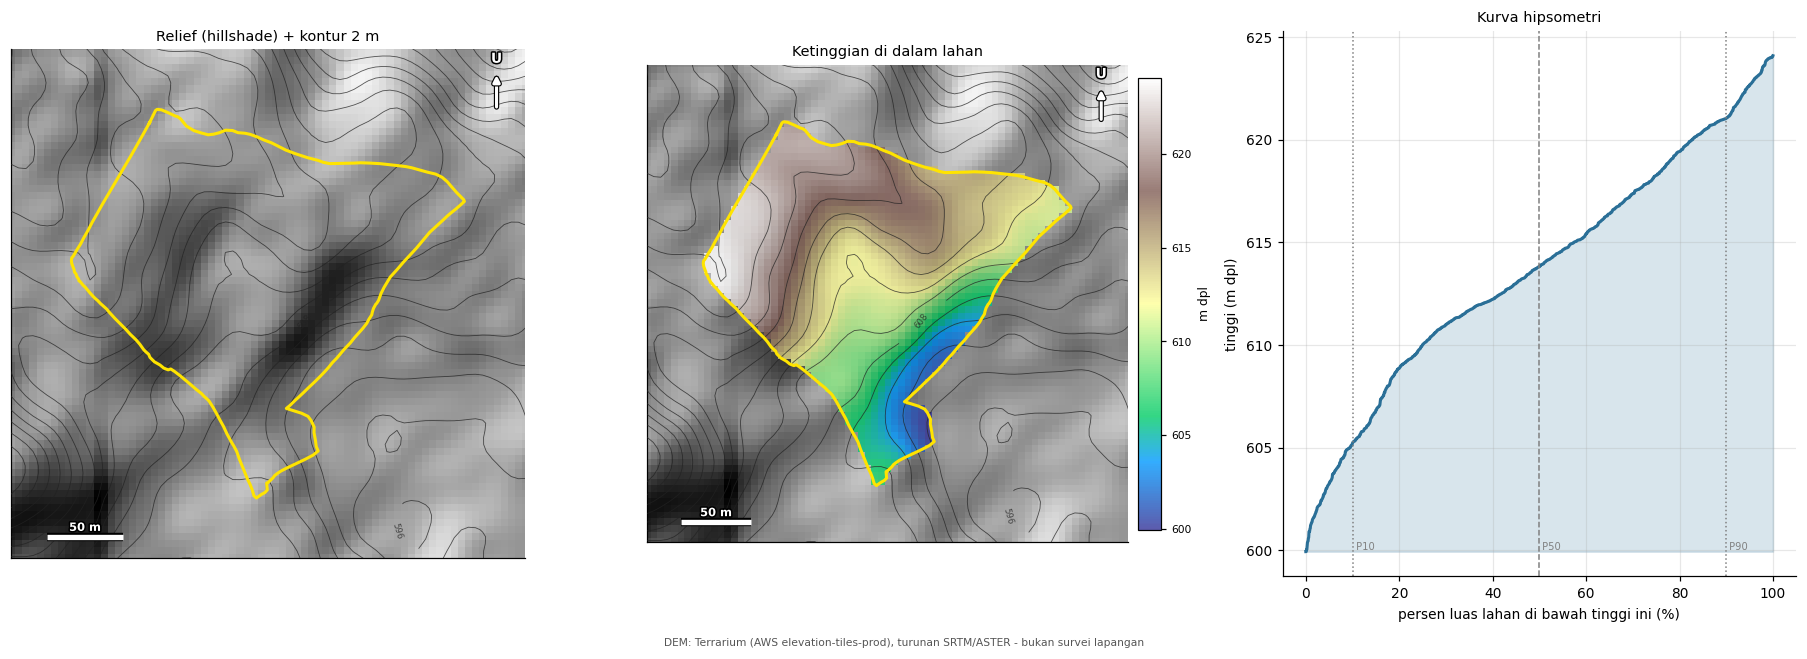

In [8]:
ZL = np.where(DI_LAHAN, ZDEM, np.nan)          # elevasi di dalam lahan saja
Z_MIN, Z_MAX = float(np.nanmin(ZL)), float(np.nanmax(ZL))
BEDA_TINGGI  = Z_MAX - Z_MIN

def gambar_batas(ax, warna="#ffe400", lw=2.0, z=6):
    ax.plot(Xc, Yc, color=warna, lw=lw, zorder=z)

def peta_terrain(ax, judul, data=None, cmap="terrain", satuan="", vmin=None, vmax=None,
                 hillshade=True, kontur=True, skala_kanan=False):
    ls = LightSource(azdeg=315, altdeg=45)
    if hillshade:
        hs = ls.hillshade(ZDEM, vert_exag=2.0, dx=RES, dy=RES)
        ax.imshow(hs, extent=EXT_DEM, cmap="gray", origin="upper", zorder=0, alpha=1.0)
    if data is not None:
        im = ax.imshow(np.where(DI_LAHAN, data, np.nan), extent=EXT_DEM, cmap=cmap,
                       origin="upper", vmin=vmin, vmax=vmax, alpha=0.80,
                       zorder=2, interpolation="nearest")
        cb = plt.colorbar(im, ax=ax, fraction=0.044, pad=0.02)
        cb.set_label(satuan, fontsize=8); cb.ax.tick_params(labelsize=7)
    if kontur:
        lv = np.arange(np.floor(ZDEM.min()/BEDA_KONTUR)*BEDA_KONTUR,
                       ZDEM.max()+BEDA_KONTUR, BEDA_KONTUR)
        cs = ax.contour(GX, GY, ZDEM, levels=lv, colors="#222222",
                        linewidths=0.55, alpha=0.75, zorder=4)
        ax.clabel(cs, cs.levels[::2], fmt="%.0f", fontsize=5.6, inline=True)
    gambar_batas(ax)
    ax.set_xlim(X.min()-MARGIN_PETA, X.max()+MARGIN_PETA)
    ax.set_ylim(Y.min()-MARGIN_PETA, Y.max()+MARGIN_PETA)
    ax.set_aspect("equal"); ax.set_title(judul, fontsize=9.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    # geser batang skala ke kanan kalau sudut kiri-bawah dipakai legenda
    batang_skala(ax, (X.max()-50+MARGIN_PETA*0.4) if skala_kanan
                 else (X.min()-MARGIN_PETA*0.4),
                 Y.min()-MARGIN_PETA*0.65, 50, "white")
    panah_utara(ax)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(16.5, 6.0))
peta_terrain(axes[0], "Relief (hillshade) + kontur 2 m", data=None, kontur=True)
peta_terrain(axes[1], "Ketinggian di dalam lahan", data=ZDEM, cmap="terrain",
             satuan="m dpl", vmin=Z_MIN, vmax=Z_MAX)

ax = axes[2]
h = ZL[np.isfinite(ZL)]
urut = np.sort(h)
ax.plot(np.linspace(0, 100, urut.size), urut, lw=2, color="#2a6f97")
ax.fill_between(np.linspace(0, 100, urut.size), urut.min(), urut, alpha=0.18,
                color="#2a6f97")
for q, w in ((50, "--"), (10, ":"), (90, ":")):
    ax.axvline(q, color="grey", ls=w, lw=1)
    ax.text(q, urut.min(), f" P{q}", fontsize=6.5, color="grey", va="bottom")
ax.set_xlabel("persen luas lahan di bawah tinggi ini (%)")
ax.set_ylabel("tinggi (m dpl)")
ax.set_title("Kurva hipsometri", fontsize=9.5); ax.set_aspect("auto")

print("=" * 62)
print("              KETINGGIAN DI DALAM LAHAN")
print("=" * 62)
print(f"  Tertinggi        : {Z_MAX:>8.1f} m dpl")
print(f"  Terendah         : {Z_MIN:>8.1f} m dpl")
print(f"  BEDA TINGGI      : {BEDA_TINGGI:>8.1f} m   <- tinggi terjun kotor")
print(f"  Rata-rata        : {np.nanmean(ZL):>8.1f} m dpl")
print(f"  Median           : {np.nanmedian(ZL):>8.1f} m dpl")
print("-" * 62)
print(f"  Beda tinggi ini {BEDA_TINGGI/SEBAR_TEGAK:.0f}x lebih besar dari sebar antar-dataset")
print(f"  (~{SEBAR_TEGAK:.1f} m) -> lerengnya NYATA, bukan derau DEM.")
print("=" * 62)

fig.text(0.5, 0.015, "DEM: Terrarium (AWS elevation-tiles-prod), turunan SRTM/ASTER "
         "- bukan survei lapangan", ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.03, 1, 1])
simpan_gambar(fig, "02_relief_kontur"); plt.show()

---
## 7. Kemiringan (slope)

Kemiringan dihitung dari gradien permukaan:

$$S = \arctan\sqrt{\left(\frac{\partial z}{\partial x}\right)^2 + \left(\frac{\partial z}{\partial y}\right)^2}$$

Dilaporkan dua-duanya: **derajat** (untuk klasifikasi lahan) dan **persen** (untuk hidrolika).
Dihitung pada dua skala, dan bedanya penting:

- **skala grid (~4,7 m)** — mengikuti tiap piksel; sebagian isinya adalah interpolasi.
- **skala ~30 m** — dihaluskan dulu sampai sepadan resolusi sumber. **Angka inilah yang
  dipakai melaporkan**, karena hanya sampai situ datanya benar-benar ada.

Kelas kemiringan memakai pembagian yang lazim dipakai untuk kesesuaian lahan di Indonesia
(0–3 % datar, 3–8 % landai, 8–15 % agak curam, 15–30 % curam, >30 % sangat curam).

                    KEMIRINGAN LAHAN
  Skala grid (4.7 m)  : rata-rata  7.05 deg | maks 17.15 deg
  Skala 30 m (dipakai): rata-rata  6.38 deg | maks 12.87 deg
                        =  11.2 % (rata-rata) |  22.8 % (maks)
------------------------------------------------------------------
  datar 0-3%         :   1.8 % luas lahan
  landai 3-8%        :  31.1 % luas lahan
  agak curam 8-15%   :  42.9 % luas lahan
  curam 15-30%       :  24.3 % luas lahan
  sangat curam >30%  :   0.0 % luas lahan
------------------------------------------------------------------
  Luas datar (peta)      :     33,163 m2
  Luas permukaan miring  :     33,409 m2  (+0.7 %)
[gambar] 03_kemiringan.png                    142 KB


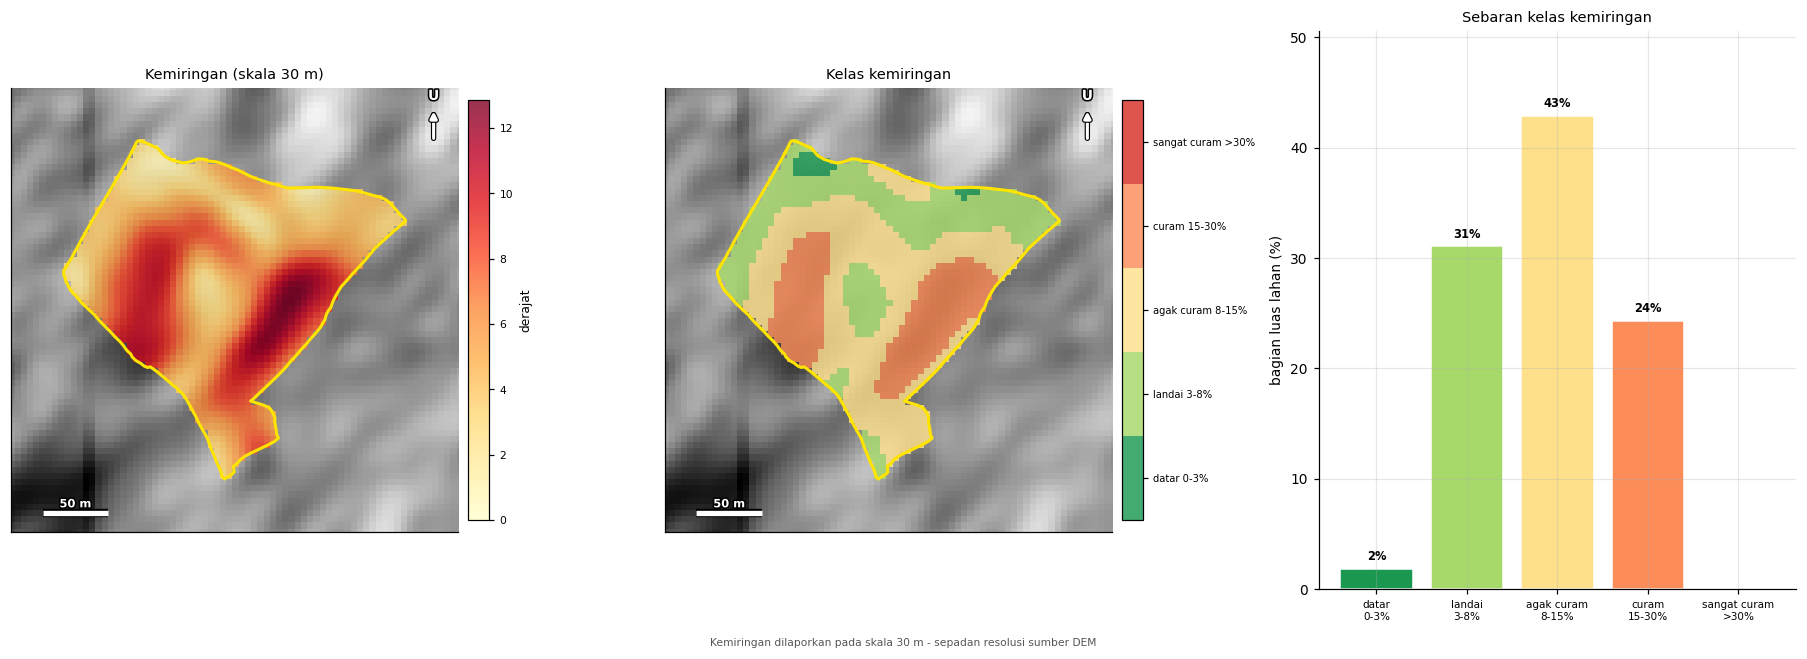

In [9]:
from scipy.ndimage import gaussian_filter

def kemiringan(Zg, res):
    dzdy, dzdx = np.gradient(Zg, res)      # baris = y (ke bawah), kolom = x
    dzdy = -dzdy                           # baris menurun ke selatan -> balik tanda
    besar = np.hypot(dzdx, dzdy)
    return np.degrees(np.arctan(besar)), dzdx, dzdy

SLOPE_HALUS_M = 30.0
sigma = (SLOPE_HALUS_M / RES) / 2.355      # FWHM ~ 30 m
Z_HALUS = gaussian_filter(ZDEM, sigma=sigma, mode="nearest")

SLOPE_GRID, dzdx_g, dzdy_g = kemiringan(ZDEM,   RES)
SLOPE_30,   dzdx,   dzdy   = kemiringan(Z_HALUS, RES)

sl_lahan_grid = SLOPE_GRID[DI_LAHAN]
sl_lahan      = SLOPE_30[DI_LAHAN]
SLOPE_RERATA  = float(np.mean(sl_lahan))
SLOPE_PERSEN  = math.tan(math.radians(SLOPE_RERATA))*100

BATAS_KELAS = [0, 3, 8, 15, 30, 100]        # persen
NAMA_KELAS  = ["datar\n0-3%", "landai\n3-8%", "agak curam\n8-15%",
               "curam\n15-30%", "sangat curam\n>30%"]
WARNA_KELAS = ["#1a9850", "#a6d96a", "#fee08b", "#fc8d59", "#d73027"]

sl_pct_grid = np.tan(np.radians(SLOPE_30))*100
kelas = np.digitize(sl_pct_grid, BATAS_KELAS[1:-1])

fig, axes = plt.subplots(1, 3, figsize=(16.5, 6.0))
peta_terrain(axes[0], f"Kemiringan (skala {SLOPE_HALUS_M:.0f} m)", data=SLOPE_30,
             cmap="YlOrRd", satuan="derajat", vmin=0, hillshade=True, kontur=False)

ax = axes[1]
ls = LightSource(azdeg=315, altdeg=45)
ax.imshow(ls.hillshade(ZDEM, vert_exag=2.0, dx=RES, dy=RES), extent=EXT_DEM,
          cmap="gray", origin="upper", zorder=0)
im = ax.imshow(np.where(DI_LAHAN, kelas, np.nan), extent=EXT_DEM, origin="upper",
               cmap=ListedColormap(WARNA_KELAS), vmin=-0.5, vmax=4.5, alpha=0.82, zorder=2,
               interpolation="nearest")
cb = plt.colorbar(im, ax=ax, fraction=0.044, pad=0.02, ticks=range(5))
cb.ax.set_yticklabels([n.replace("\n", " ") for n in NAMA_KELAS], fontsize=6.5)
gambar_batas(ax)
ax.set_xlim(X.min()-MARGIN_PETA, X.max()+MARGIN_PETA)
ax.set_ylim(Y.min()-MARGIN_PETA, Y.max()+MARGIN_PETA)
ax.set_aspect("equal"); ax.set_title("Kelas kemiringan", fontsize=9.5)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
batang_skala(ax, X.min()-MARGIN_PETA*0.4, Y.min()-MARGIN_PETA*0.65, 50)
panah_utara(ax)

ax = axes[2]
sl_pct_lahan = np.tan(np.radians(sl_lahan))*100
bagi = pd.Series(np.digitize(sl_pct_lahan, BATAS_KELAS[1:-1])).value_counts(normalize=True)
bagi = (bagi.reindex(range(5)).fillna(0) * 100)
ax.bar(range(5), bagi.values, color=WARNA_KELAS, edgecolor="white")
for i, v in enumerate(bagi.values):
    if v > 0.4:
        ax.text(i, v+0.8, f"{v:.0f}%", ha="center", fontsize=7.5, weight="bold")
ax.set_xticks(range(5)); ax.set_xticklabels(NAMA_KELAS, fontsize=6.8)
ax.set_ylabel("bagian luas lahan (%)")
ax.set_title("Sebaran kelas kemiringan", fontsize=9.5); ax.set_aspect("auto")
ax.set_ylim(0, max(bagi.values)*1.18)

# luas permukaan sebenarnya vs luas datar.
# Faktor dihitung per sel (rata-rata 1/cos S), lalu dikalikan ke luas poligon supaya
# kedua angka berpijak pada dasar yang sama - bukan luas poligon vs jumlah sel DEM.
FAKTOR_LERENG  = float(np.mean(1.0/np.cos(np.radians(SLOPE_30[DI_LAHAN]))))
LUAS_PERMUKAAN = LUAS_M2 * FAKTOR_LERENG

print("=" * 66)
print("                    KEMIRINGAN LAHAN")
print("=" * 66)
print(f"  Skala grid ({RES:.1f} m)  : rata-rata {np.mean(sl_lahan_grid):5.2f} deg | "
      f"maks {np.max(sl_lahan_grid):5.2f} deg")
print(f"  Skala {SLOPE_HALUS_M:.0f} m (dipakai): rata-rata {SLOPE_RERATA:5.2f} deg | "
      f"maks {np.max(sl_lahan):5.2f} deg")
print(f"                        = {SLOPE_PERSEN:5.1f} % (rata-rata) | "
      f"{math.tan(math.radians(np.max(sl_lahan)))*100:5.1f} % (maks)")
print("-" * 66)
for i, n in enumerate(NAMA_KELAS):
    print(f"  {n.replace(chr(10), ' '):<18} : {bagi.values[i]:5.1f} % luas lahan")
print("-" * 66)
print(f"  Luas datar (peta)      : {LUAS_M2:>10,.0f} m2")
print(f"  Luas permukaan miring  : {LUAS_PERMUKAAN:>10,.0f} m2  "
      f"(+{100*(FAKTOR_LERENG-1):.1f} %)")
print("=" * 66)

fig.text(0.5, 0.015, "Kemiringan dilaporkan pada skala 30 m - sepadan resolusi sumber DEM",
         ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.03, 1, 1])
simpan_gambar(fig, "03_kemiringan"); plt.show()

---
## 8. Arah hadap (aspect)

Aspect = ke arah mana permukaan menghadap, diukur searah jarum jam dari utara.
Untuk irigasi ini bukan sekadar hiasan:

- **arah hadap = arah air mengalir** kalau tidak ditahan;
- lereng menghadap **barat** menerima matahari sore yang lebih terik — penguapan lebih besar;
- **satu arah hadap dominan** berarti lahan berupa satu bidang lereng, sehingga arah
  galengan/teras bisa seragam. Arah hadap yang **berpencar** berarti ada beberapa
  punggungan/cekungan dan lahan harus dibagi per blok.

Tiap sel DEM luasnya sama, jadi **mencacah sel = menimbang luas** — panjang batang pada
mawar angin langsung terbaca sebagai persen luas lahan. Hanya sel dengan kemiringan di
atas 1° yang ikut: permukaan hampir datar tidak punya arah hadap yang berarti, dan kalau
diikutkan justru menambah derau ke arah rata-rata.

Arah rata-rata dihitung sebagai **rata-rata vektor**, bukan rata-rata sudut — sudut 350°
dan 10° rata-ratanya 0°, bukan 180°. Panjang vektor hasilnya (`keterpusatan`, 0–1)
sekaligus mengukur seberapa seragam lerengnya.

                     ARAH HADAP LERENG
  Arah rata-rata      : 127 derajat dari utara  ->  menghadap TG
  Keterpusatan arah   : 0.83  (1 = satu bidang lereng, 0 = berpencar)
  Penjuru terbanyak   : TG (47 % luas)
  Piksel hampir datar : 0.1 % (kemiringan < 1 deg, tidak diikutkan)
------------------------------------------------------------------
  Arah hadap CUKUP TERPUSAT: arah utamanya jelas (TG), tetapi masih
  ada sisa sebaran - permukaan tidak rata sempurna satu bidang.
  Seberapa besar puntirannya diukur pada potongan B-B' di bagian 10.
[gambar] 04_arah_hadap.png                    233 KB


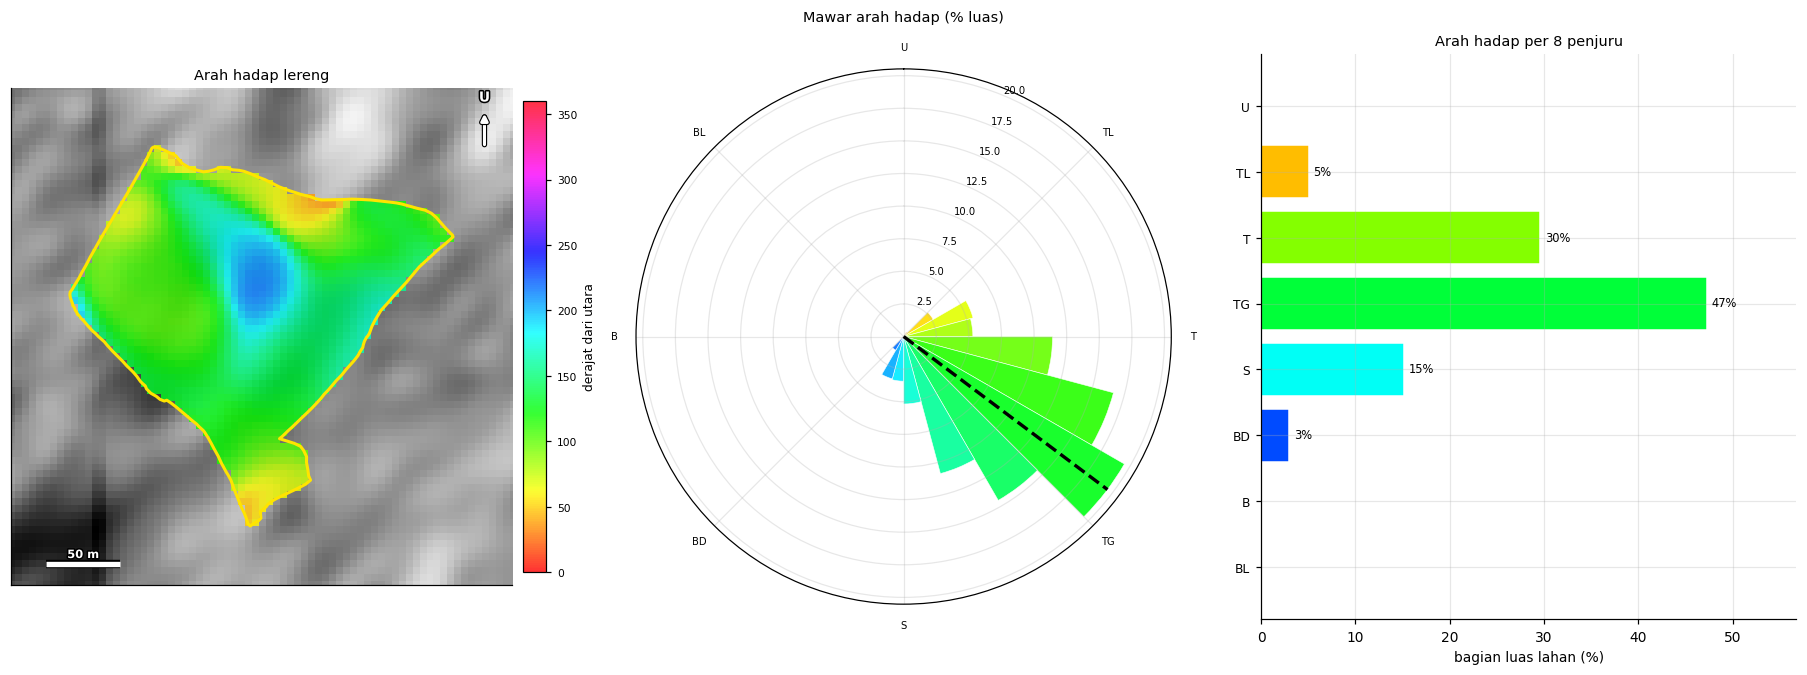

In [10]:
ASPECT = (np.degrees(np.arctan2(-dzdx, -dzdy))) % 360.0   # 0=utara, searah jarum jam
ARAH_8 = ["U", "TL", "T", "TG", "S", "BD", "B", "BL"]

berarti = DI_LAHAN & (SLOPE_30 > 1.0)
asp = ASPECT[berarti]
w   = np.ones_like(asp)

# arah rata-rata (rata-rata vektor, bukan rata-rata sudut)
vx, vy = np.sin(np.radians(asp)).mean(), np.cos(np.radians(asp)).mean()
ASPEK_RERATA = math.degrees(math.atan2(vx, vy)) % 360
KETERPUSATAN = math.hypot(vx, vy)          # 1 = satu arah, 0 = berpencar
sektor = ARAH_8[int(((ASPEK_RERATA + 22.5) % 360)//45)]

fig = plt.figure(figsize=(16.5, 6.0))
ax0 = fig.add_subplot(1, 3, 1)
peta_terrain(ax0, "Arah hadap lereng", data=ASPECT, cmap="hsv", satuan="derajat dari utara",
             vmin=0, vmax=360, hillshade=True, kontur=False)

ax1 = fig.add_subplot(1, 3, 2, projection="polar")
tepi = np.arange(0, 361, 15)
cacah, _ = np.histogram(asp, bins=tepi, weights=w)
cacah = cacah / cacah.sum() * 100
pusat = np.radians(tepi[:-1] + 7.5)
ax1.bar(pusat, cacah, width=np.radians(15), bottom=0.0,
        color=plt.get_cmap("hsv")((tepi[:-1]+7.5)/360), edgecolor="white", lw=0.4, alpha=0.9)
ax1.set_theta_zero_location("N"); ax1.set_theta_direction(-1)
ax1.set_xticks(np.radians(np.arange(0, 360, 45)))
ax1.set_xticklabels(ARAH_8, fontsize=8)
ax1.set_title("Mawar arah hadap (% luas)", fontsize=9.5, pad=14)
ax1.tick_params(labelsize=6.5)
ax1.plot([np.radians(ASPEK_RERATA)]*2, [0, cacah.max()], color="black", lw=2.2, ls="--")

ax2 = fig.add_subplot(1, 3, 3)
sekt_idx = ((asp + 22.5) % 360)//45
por = pd.Series(sekt_idx).value_counts(normalize=True).reindex(range(8)).fillna(0)*100
ax2.barh(range(8), por.values, color=plt.get_cmap("hsv")(np.arange(8)/8),
         edgecolor="white")
for i, v in enumerate(por.values):
    if v > 0.5:
        ax2.text(v+0.5, i, f"{v:.0f}%", va="center", fontsize=7.5)
ax2.set_yticks(range(8)); ax2.set_yticklabels(ARAH_8, fontsize=8)
ax2.invert_yaxis(); ax2.set_xlabel("bagian luas lahan (%)")
ax2.set_title("Arah hadap per 8 penjuru", fontsize=9.5); ax2.set_aspect("auto")
ax2.set_xlim(0, max(por.values)*1.2)

print("=" * 66)
print("                     ARAH HADAP LERENG")
print("=" * 66)
print(f"  Arah rata-rata      : {ASPEK_RERATA:.0f} derajat dari utara  ->  menghadap {sektor}")
print(f"  Keterpusatan arah   : {KETERPUSATAN:.2f}  (1 = satu bidang lereng, 0 = berpencar)")
print(f"  Penjuru terbanyak   : {ARAH_8[int(por.idxmax())]} ({por.max():.0f} % luas)")
print(f"  Piksel hampir datar : {100*(DI_LAHAN.sum()-berarti.sum())/DI_LAHAN.sum():.1f} % "
      f"(kemiringan < 1 deg, tidak diikutkan)")
print("-" * 66)
if KETERPUSATAN > 0.85:
    print("  Arah hadap SANGAT TERPUSAT -> lahan praktis satu bidang lereng.")
    print(f"  Galengan/teras searah kontur, tegak lurus arah {sektor}.")
elif KETERPUSATAN > 0.6:
    print(f"  Arah hadap CUKUP TERPUSAT: arah utamanya jelas ({sektor}), tetapi masih")
    print("  ada sisa sebaran - permukaan tidak rata sempurna satu bidang.")
    print("  Seberapa besar puntirannya diukur pada potongan B-B' di bagian 10.")
else:
    print("  Arah hadap BERPENCAR -> ada lebih dari satu bidang lereng.")
    print("  Lahan perlu dibagi per blok; satu arah galengan tidak cukup.")
print("=" * 66)

plt.tight_layout()
simpan_gambar(fig, "04_arah_hadap"); plt.show()

---
## 9. Ke mana air mengalir

Tiga langkah baku analisis aliran permukaan:

1. **Isi cekungan** (*priority flood*). DEM selalu punya cekungan palsu akibat derau;
   kalau dibiarkan, jalur aliran putus di tengah jalan. Cekungan diisi sampai air bisa
   keluar — dicatat berapa banyak yang terisi, karena kalau isiannya besar berarti DEM-nya
   memang kasar di situ. Pengisian dilakukan **dua kali**: sekali apa adanya untuk
   *mengukur* kedalaman cekungan, sekali lagi dengan kemiringan buatan 0,1 mm per sel
   untuk *menelusuri* aliran — tanpa itu bekas cekungan menjadi bidang datar sempurna
   dan penelusuran berhenti di situ, tidak pernah sampai ke titik keluar.
2. **Arah aliran D8.** Tiap sel mengalirkan air ke satu dari 8 tetangga dengan penurunan
   per jarak terbesar.
3. **Akumulasi aliran.** Berapa banyak sel yang bermuara lewat tiap sel — nilai besar
   menandai **alur alami**, tempat air berkumpul saat hujan.

Yang dicari dari sini: **di mana air masuk dan keluar dari lahan**, dan **di mana alur
alaminya** — karena melawan alur alami adalah cara termahal membangun saluran.

> Pada DEM ~30 m, alur yang muncul adalah alur **skala bentang lahan**, bukan parit
> kecil di dalam petak. Dipakai untuk menentukan arah umum, bukan menempatkan saluran.
>
> **Garis-garis sejajar miring pada peta akumulasi adalah cacat metode D8, bukan
> bentang alam.** Karena tiap sel hanya boleh memilih satu dari delapan arah, aliran di
> lereng yang halus "dibulatkan" ke arah terdekat lalu menumpuk menjadi jalur lurus
> berulang. Yang boleh dibaca dari peta itu hanya **alur utama yang tebal dan menerus**;
> garis-garis tipis sejajar diabaikan.

Cekungan terisi : 541 sel (2.1 % grid), terdalam 3.50 m
Sel buntu di dalam lahan (tanpa arah aliran) : 0 -> aman
Akumulasi maks di dalam lahan : 2,236 sel = 4.99 ha daerah tangkapan
[gambar] 05_arah_aliran.png                   439 KB


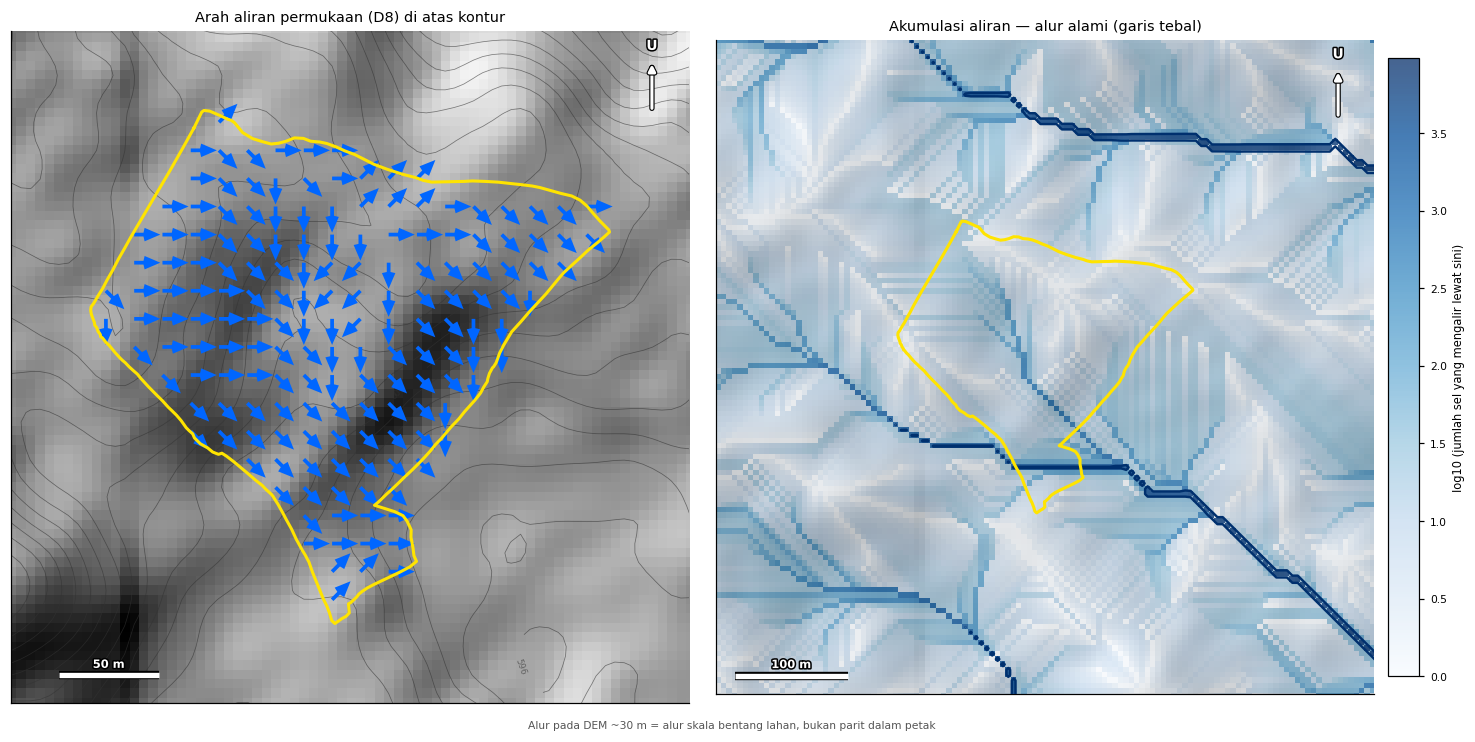

In [11]:
def isi_cekungan(Zg, eps=0.0):
    """Priority flood: isi cekungan supaya tiap sel punya jalan keluar.

    `eps` > 0 memberi kemiringan buatan yang sangat kecil pada bagian yang terisi,
    supaya tidak tersisa bidang datar sempurna. Ini bukan hiasan: pengisian biasa
    menghasilkan permukaan rata: di situ D8 tidak menemukan tetangga yang lebih
    rendah, sehingga penelusuran jalur aliran BERHENTI di tengah cekungan dan tidak
    pernah sampai ke titik keluar.
    """
    ny, nx = Zg.shape
    keluar = np.full(Zg.shape, np.inf)
    sudah  = np.zeros(Zg.shape, bool)
    antre  = []
    for i in range(ny):
        for j in (0, nx-1):
            heapq.heappush(antre, (Zg[i, j], i, j)); sudah[i, j] = True
    for j in range(nx):
        for i in (0, ny-1):
            if not sudah[i, j]:
                heapq.heappush(antre, (Zg[i, j], i, j)); sudah[i, j] = True
    while antre:
        z, i, j = heapq.heappop(antre)
        keluar[i, j] = z
        for di, dj in ((-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)):
            ii, jj = i+di, j+dj
            if 0 <= ii < ny and 0 <= jj < nx and not sudah[ii, jj]:
                sudah[ii, jj] = True
                heapq.heappush(antre, (max(Zg[ii, jj], z + eps), ii, jj))
    return keluar

Z_ISI  = isi_cekungan(Z_HALUS)                 # untuk MENGUKUR kedalaman cekungan
TERISI = Z_ISI - Z_HALUS
Z_D8   = isi_cekungan(Z_HALUS, eps=1e-4)       # untuk MENELUSURI arah aliran

ARAH = [(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1),(-1,-1)]   # U, TL, T, TG, S, BD, B, BL
ny, nx = Z_ISI.shape

def arah_d8(Zg, res):
    ke = np.full(Zg.shape, -1, int)
    for i in range(ny):
        for j in range(nx):
            terbaik, arah = 0.0, -1
            for k, (di, dj) in enumerate(ARAH):
                ii, jj = i+di, j+dj
                if not (0 <= ii < ny and 0 <= jj < nx):
                    continue
                jarak = res*math.hypot(di, dj)
                turun = (Zg[i, j] - Zg[ii, jj]) / jarak
                if turun > terbaik:
                    terbaik, arah = turun, k
            ke[i, j] = arah
    return ke

D8 = arah_d8(Z_D8, RES)
buntu = int(((D8 < 0) & DI_LAHAN).sum())

def akumulasi(ke, Zg):
    """Jumlah sel yang mengalir lewat tiap sel (diproses dari tinggi ke rendah)."""
    akum = np.ones(Zg.shape, float)
    urut = np.argsort(Zg.ravel())[::-1]
    for idx in urut:
        i, j = divmod(int(idx), nx)
        k = ke[i, j]
        if k >= 0:
            di, dj = ARAH[k]
            akum[i+di, j+dj] += akum[i, j]
    return akum

AKUM = akumulasi(D8, Z_D8)
LUAS_ALIRAN = AKUM * RES * RES        # m2 daerah tangkapan tiap sel

print(f"Cekungan terisi : {(TERISI > 0.01).sum():,} sel "
      f"({100*(TERISI>0.01).sum()/TERISI.size:.1f} % grid), "
      f"terdalam {TERISI.max():.2f} m")
print(f"Sel buntu di dalam lahan (tanpa arah aliran) : {buntu} "
      f"-> {'aman' if buntu == 0 else 'PERIKSA: jalur aliran bisa terputus'}")
print(f"Akumulasi maks di dalam lahan : {AKUM[DI_LAHAN].max():,.0f} sel "
      f"= {LUAS_ALIRAN[DI_LAHAN].max()/10_000:.2f} ha daerah tangkapan")

# --- gambar ---
fig, axes = plt.subplots(1, 2, figsize=(13.6, 6.6))

ax = axes[0]
ls = LightSource(azdeg=315, altdeg=45)
ax.imshow(ls.hillshade(ZDEM, vert_exag=2.0, dx=RES, dy=RES), extent=EXT_DEM,
          cmap="gray", origin="upper", zorder=0)
lv = np.arange(np.floor(ZDEM.min()/BEDA_KONTUR)*BEDA_KONTUR,
               ZDEM.max()+BEDA_KONTUR, BEDA_KONTUR)
cs = ax.contour(GX, GY, ZDEM, levels=lv, colors="#333333", linewidths=0.5, alpha=0.6, zorder=2)
ax.clabel(cs, cs.levels[::2], fmt="%.0f", fontsize=5.6, inline=True)
lom = max(1, int(round(12.0/RES)))          # panah tiap ~12 m
sx = np.array([[ARAH[k][1] if k >= 0 else 0 for k in baris] for baris in D8], float)
sy = np.array([[-ARAH[k][0] if k >= 0 else 0 for k in baris] for baris in D8], float)
pjg = np.hypot(sx, sy); pjg[pjg == 0] = 1
mask_p = DI_LAHAN[::lom, ::lom]
ax.quiver(GX[::lom, ::lom][mask_p], GY[::lom, ::lom][mask_p],
          (sx/pjg)[::lom, ::lom][mask_p], (sy/pjg)[::lom, ::lom][mask_p],
          color="#0066ff", scale=26, width=0.0055, zorder=5,
          headwidth=3.6, headlength=4.2)
gambar_batas(ax)
ax.set_xlim(X.min()-MARGIN_PETA, X.max()+MARGIN_PETA)
ax.set_ylim(Y.min()-MARGIN_PETA, Y.max()+MARGIN_PETA)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("Arah aliran permukaan (D8) di atas kontur", fontsize=9.5)
batang_skala(ax, X.min()-MARGIN_PETA*0.4, Y.min()-MARGIN_PETA*0.65, 50)
panah_utara(ax)

ax = axes[1]
ax.imshow(ls.hillshade(ZDEM, vert_exag=2.0, dx=RES, dy=RES), extent=EXT_DEM,
          cmap="gray", origin="upper", zorder=0)
im = ax.imshow(np.log10(AKUM), extent=EXT_DEM, origin="upper", cmap="Blues",
               alpha=0.75, zorder=2, interpolation="nearest")
cb = plt.colorbar(im, ax=ax, fraction=0.044, pad=0.02)
cb.set_label("log10 (jumlah sel yang mengalir lewat sini)", fontsize=7.5)
cb.ax.tick_params(labelsize=7)
AMBANG_ALUR = np.percentile(AKUM, 99.0)
ax.contour(GX, GY, AKUM, levels=[AMBANG_ALUR], colors="#00306e", linewidths=1.6, zorder=4)
gambar_batas(ax)
ax.set_xlim(X.min()-MARGIN_PETA*4, X.max()+MARGIN_PETA*4)
ax.set_ylim(Y.min()-MARGIN_PETA*4, Y.max()+MARGIN_PETA*4)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("Akumulasi aliran — alur alami (garis tebal)", fontsize=9.5)
batang_skala(ax, X.min()-MARGIN_PETA*3.6, Y.min()-MARGIN_PETA*3.6, 100)
panah_utara(ax)

fig.text(0.5, 0.015, "Alur pada DEM ~30 m = alur skala bentang lahan, bukan parit dalam petak",
         ha="center", fontsize=7, color="#555")
plt.tight_layout(rect=[0, 0.03, 1, 1])
simpan_gambar(fig, "05_arah_aliran"); plt.show()

---
## 10. Potongan melintang lahan

Peta menunjukkan sebaran; **potongan** menunjukkan bentuknya. Dua irisan lewat titik
berat lahan:

- **Searah lereng** (mengikuti arah hadap rata-rata) — memperlihatkan seberapa panjang
  dan seberapa terus-menerus turunannya. Kalau garisnya lurus, lerengnya seragam;
  kalau berundak, sudah ada teras.
- **Searah kontur** (tegak lurus arah lereng) — idealnya mendatar. Kalau irisan ini
  ternyata ikut miring, lahan **memuntir**: satu garis galengan lurus tidak akan
  mendatar di kedua ujungnya.

Nisbah tegak (*vertical exaggeration*) dicantumkan supaya lereng tidak terbaca lebih
dramatis daripada aslinya.

                    POTONGAN MELINTANG
  A-A' searah lereng : turun  19.1 m sepanjang   188 m ->  10.1 %
  B-B' searah kontur : beda    6.6 m sepanjang   172 m ->   3.8 %
--------------------------------------------------------------------
  Kemiringan melintang 3.8 % terhadap 10.1 % searah lereng
  -> arah lereng setempat menyimpang ~21 deg dari arah rata-rata
  Permukaan MEMUNTIR. Satu garis galengan LURUS tidak akan mendatar di
  kedua ujungnya -> galengan harus mengikuti garis kontur.
[gambar] 06_potongan_melintang.png            365 KB


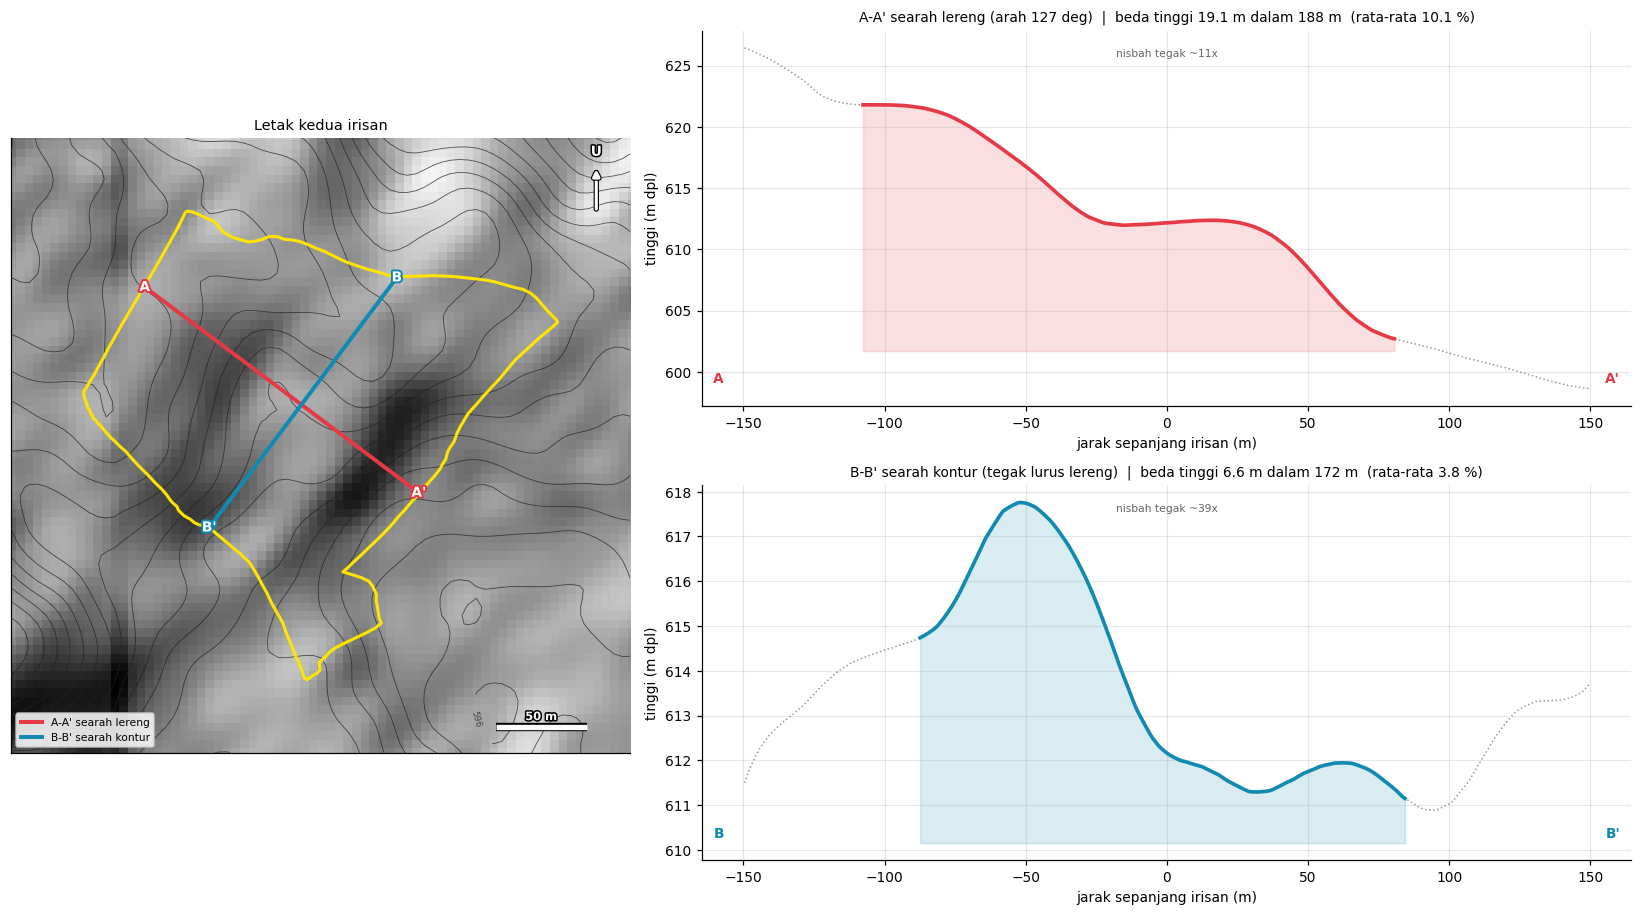

In [12]:
def sampel_dem(Zg, xq, yq):
    """Ambil nilai DEM di titik sembarang (bilinear)."""
    fx = (np.asarray(xq) - xs_dem[0]) / RES
    fy = (ys_dem[0] - np.asarray(yq)) / RES        # ys_dem menurun
    fx = np.clip(fx, 0, Zg.shape[1]-1.001); fy = np.clip(fy, 0, Zg.shape[0]-1.001)
    j0, i0 = fx.astype(int), fy.astype(int)
    tx, ty = fx-j0, fy-i0
    return ((Zg[i0, j0]*(1-tx) + Zg[i0, j0+1]*tx)*(1-ty) +
            (Zg[i0+1, j0]*(1-tx) + Zg[i0+1, j0+1]*tx)*ty)

def potong(sudut_deg, panjang=None, n=400):
    """Garis lewat titik berat lahan pada arah `sudut_deg` (dari utara, searah jarum jam)."""
    if panjang is None:
        panjang = 1.15*max(X.max()-X.min(), Y.max()-Y.min())
    ux, uy = math.sin(math.radians(sudut_deg)), math.cos(math.radians(sudut_deg))
    s = np.linspace(-panjang/2, panjang/2, n)
    xq, yq = CX + s*ux, CY + s*uy
    z = sampel_dem(ZDEM, xq, yq)
    di = dalam_poligon(xq, yq, RING)
    return s, z, di, xq, yq

s1, z1, in1, xq1, yq1 = potong(ASPEK_RERATA)              # searah lereng (menurun)
s2, z2, in2, xq2, yq2 = potong((ASPEK_RERATA+90) % 360)   # searah kontur

fig = plt.figure(figsize=(15.0, 8.4))
gs  = fig.add_gridspec(2, 2, width_ratios=[1, 1.5])
ax_peta = fig.add_subplot(gs[:, 0])          # peta memakai kolom kiri penuh
ax_A    = fig.add_subplot(gs[0, 1])
ax_B    = fig.add_subplot(gs[1, 1])

peta_terrain(ax_peta, "Letak kedua irisan", data=None, kontur=True, skala_kanan=True)
ax_peta.plot(xq1[in1], yq1[in1], color="#e63946", lw=2.6, zorder=7,
             label="A-A' searah lereng")
ax_peta.plot(xq2[in2], yq2[in2], color="#118ab2", lw=2.6, zorder=7,
             label="B-B' searah kontur")
for (xq_, yq_, in_, warna, tanda) in ((xq1, yq1, in1, "#e63946", "A"),
                                      (xq2, yq2, in2, "#118ab2", "B")):
    for ujung, lbl in ((0, tanda), (-1, tanda + "'")):
        ax_peta.text(xq_[in_][ujung], yq_[in_][ujung], lbl, fontsize=9, weight="bold",
                     color="white", ha="center", va="center", zorder=9,
                     path_effects=[pe.withStroke(linewidth=2.6, foreground=warna)])
ax_peta.legend(loc="lower left", fontsize=7, framealpha=0.85)

def gambar_potong(ax, s, z, di, warna, judul, tanda):
    ax.plot(s, z, color="#999", lw=1.0, ls=":", zorder=2)
    ax.plot(s[di], z[di], color=warna, lw=2.4, zorder=3)
    ax.fill_between(s[di], z[di].min()-1, z[di], color=warna, alpha=0.16, zorder=1)
    dz = z[di].max() - z[di].min()
    ds = s[di].max() - s[di].min()
    lereng = 100*dz/ds if ds else 0
    ax.set_xlabel("jarak sepanjang irisan (m)"); ax.set_ylabel("tinggi (m dpl)")
    ax.set_title(f"{judul}  |  beda tinggi {dz:.1f} m dalam {ds:.0f} m  "
                 f"(rata-rata {lereng:.1f} %)", fontsize=9)
    ax.set_aspect("auto")
    ax.text(0.012, 0.06, tanda, transform=ax.transAxes, fontsize=9, weight="bold",
            color=warna)
    ax.text(0.988, 0.06, tanda + "'", transform=ax.transAxes,
            fontsize=9, weight="bold", color=warna, ha="right")
    # nisbah tegak
    ve = (ax.get_xlim()[1]-ax.get_xlim()[0]) / max(ax.get_ylim()[1]-ax.get_ylim()[0], 1e-9)
    ax.text(0.5, 0.93, f"nisbah tegak ~{ve:.0f}x", transform=ax.transAxes, ha="center",
            fontsize=7, color="#666")
    return dz, ds, lereng

dz1, ds1, lr1 = gambar_potong(ax_A, s1, z1, in1, "#e63946",
                              f"A-A' searah lereng (arah {ASPEK_RERATA:.0f} deg)", "A")
dz2, ds2, lr2 = gambar_potong(ax_B, s2, z2, in2, "#118ab2",
                              "B-B' searah kontur (tegak lurus lereng)", "B")

print("=" * 68)
print("                    POTONGAN MELINTANG")
print("=" * 68)
print(f"  A-A' searah lereng : turun {dz1:5.1f} m sepanjang {ds1:5.0f} m -> {lr1:5.1f} %")
print(f"  B-B' searah kontur : beda  {dz2:5.1f} m sepanjang {ds2:5.0f} m -> {lr2:5.1f} %")
print("-" * 68)
# Kalau lahan berupa satu bidang miring sempurna, B-B' pasti mendatar. Besarnya
# kemiringan melintang dibanding kemiringan searah lereng = ukuran PUNTIRAN.
PUNTIRAN = math.degrees(math.atan2(lr2, lr1)) if lr1 > 0 else 0.0
print(f"  Kemiringan melintang {lr2:.1f} % terhadap {lr1:.1f} % searah lereng")
print(f"  -> arah lereng setempat menyimpang ~{PUNTIRAN:.0f} deg dari arah rata-rata")
if dz2 < SEBAR_TEGAK:
    print(f"  Beda pada B-B' ({dz2:.1f} m) masih di bawah ketidakpastian DEM "
          f"(~{SEBAR_TEGAK:.1f} m)")
    print("  -> lahan boleh dianggap satu bidang lereng seragam.")
elif PUNTIRAN < 15:
    print("  Puntiran kecil -> galengan lurus searah kontur masih dapat dipakai,")
    print("  asalkan elevasi kedua ujungnya dikoreksi saat pelaksanaan.")
else:
    print("  Permukaan MEMUNTIR. Satu garis galengan LURUS tidak akan mendatar di")
    print("  kedua ujungnya -> galengan harus mengikuti garis kontur.")
print("=" * 68)

plt.tight_layout()
simpan_gambar(fig, "06_potongan_melintang"); plt.show()

---
## 11. Titik tertinggi, titik terendah, dan tinggi terjun

Untuk irigasi gravitasi, dua titik menentukan segalanya: **di mana air bisa masuk**
(titik tinggi) dan **ke mana air pasti pergi** (titik rendah).

Yang dilaporkan:

- **tinggi terjun kotor** — beda tinggi maksimum di dalam lahan;
- **tinggi terjun terpakai** — dari titik masuk terbaik ke titik keluar, mengikuti
  jalur aliran alami, bukan garis lurus;
- **titik keluar (outlet)** — sel dengan akumulasi aliran terbesar yang meninggalkan lahan.

Semua ini **geometri**, bukan desain hidrolika. Debit, kehilangan tekanan, dan dimensi
bangunan tidak dihitung di sini.

              TITIK KRITIS & TINGGI TERJUN
  Titik tertinggi :   624.1 m dpl
  Titik terendah  :   599.9 m dpl
  Tinggi terjun kotor        :   24.1 m
  Jarak lurus tinggi-rendah  :    194 m -> 12.4 % rata-rata
--------------------------------------------------------------------
  Jalur aliran alami : panjang 198 m, turun 22.9 m
                       (102 % dari jarak lurus -> hampir lurus)
                       berhenti karena: keluar meninggalkan lahan
  Titik keluar (akumulasi terbesar) : 599.9 m dpl, daerah tangkapan 4.99 ha
--------------------------------------------------------------------
  PENTING: jalur ini TIDAK bermuara di titik terendah - berpisah 28 m
  darinya, dan meninggalkan lahan di elevasi 601.2 m (bukan 599.9 m).
  Artinya lahan ini punya LEBIH DARI SATU pintu keluar air: bagian hulu
  membuang lewat sisi timur, sedangkan cekungan terendah di sisi selatan
  ditampung jalur yang berbeda. Satu saluran pembuang tidak akan cukup;
  jumlah dan letak pintu buang harus 

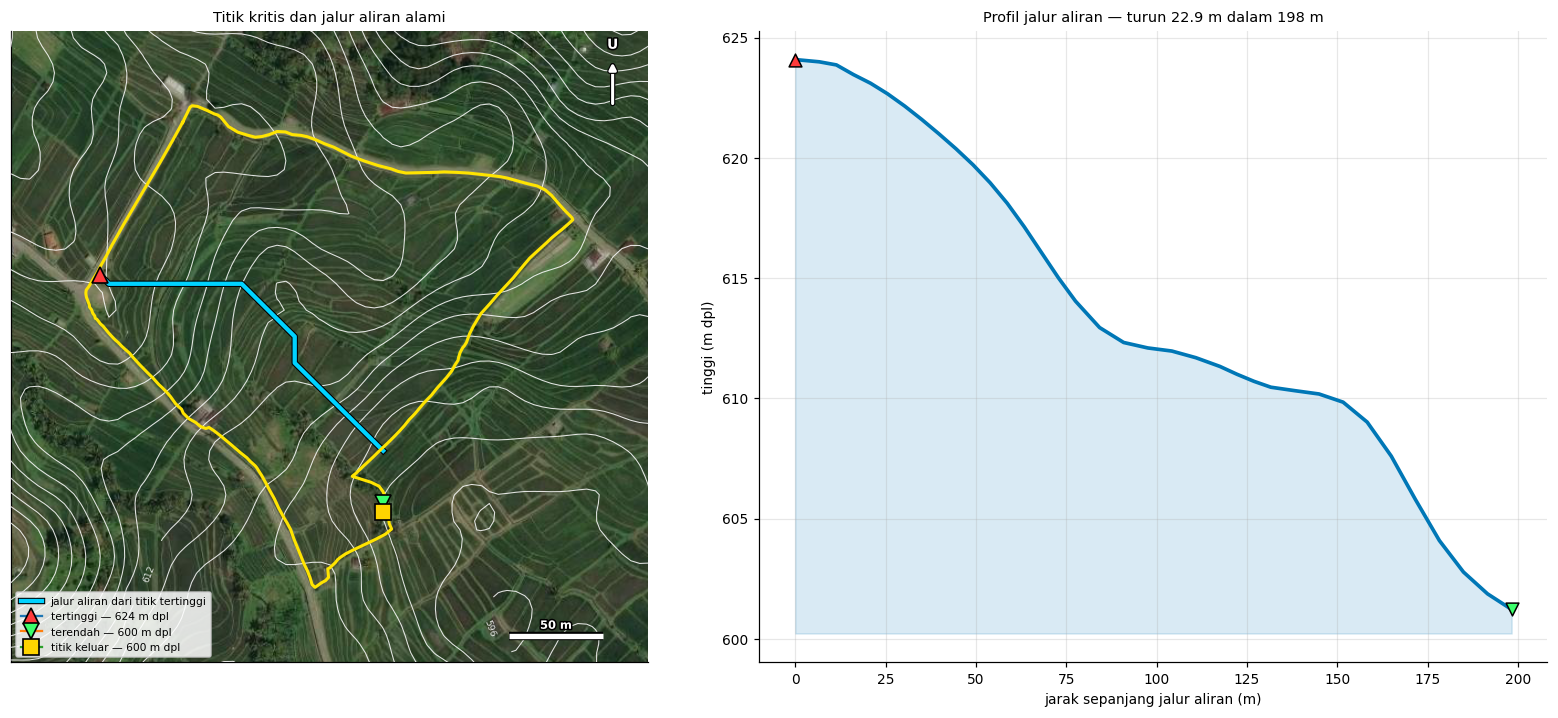

In [13]:
# --- titik ekstrem di dalam lahan ---
idx_hi = np.unravel_index(np.nanargmax(np.where(DI_LAHAN, ZDEM, -np.inf)), ZDEM.shape)
idx_lo = np.unravel_index(np.nanargmin(np.where(DI_LAHAN, ZDEM,  np.inf)), ZDEM.shape)
P_HI = (GX[idx_hi], GY[idx_hi], ZDEM[idx_hi])
P_LO = (GX[idx_lo], GY[idx_lo], ZDEM[idx_lo])

# --- outlet: akumulasi terbesar di dalam lahan ---
idx_out = np.unravel_index(np.argmax(np.where(DI_LAHAN, AKUM, -np.inf)), AKUM.shape)
P_OUT = (GX[idx_out], GY[idx_out], ZDEM[idx_out])

# --- jalur aliran dari titik tertinggi, mengikuti D8 ---
jalur = [idx_hi]; i, j = idx_hi
alasan = "mencapai batas penelusuran"
for _ in range(4000):
    k = D8[i, j]
    if k < 0:
        alasan = "sel buntu (tidak ada tetangga lebih rendah)"
        break
    di, dj = ARAH[k]; i, j = i+di, j+dj
    jalur.append((i, j))
    if not DI_LAHAN[i, j]:
        alasan = "keluar meninggalkan lahan"
        break
jx = np.array([GX[p] for p in jalur]); jy = np.array([GY[p] for p in jalur])
jz = np.array([ZDEM[p] for p in jalur])
PANJANG_JALUR = float(np.hypot(np.diff(jx), np.diff(jy)).sum())
TERJUN_JALUR  = float(jz[0] - jz[-1])

JARAK_LURUS = math.hypot(P_HI[0]-P_LO[0], P_HI[1]-P_LO[1])

fig, axes = plt.subplots(1, 2, figsize=(14.6, 6.6),
                         gridspec_kw={"width_ratios": [1, 1.1]})

ax = axes[0]
if CITRA.get("detail") is not None:
    ax.imshow(CITRA["detail"]["img"], extent=CITRA["detail"]["extent"], origin="upper",
              interpolation="bilinear", zorder=0)
lvv = np.arange(np.floor(ZDEM.min()/BEDA_KONTUR)*BEDA_KONTUR,
                ZDEM.max()+BEDA_KONTUR, BEDA_KONTUR)
cs = ax.contour(GX, GY, ZDEM, levels=lvv, colors="white", linewidths=0.7, alpha=0.85, zorder=3)
ax.clabel(cs, cs.levels[::2], fmt="%.0f", fontsize=6, inline=True, colors="white")
ax.plot(jx, jy, color="#00d2ff", lw=2.8, zorder=6, label="jalur aliran dari titik tertinggi",
        path_effects=[pe.withStroke(linewidth=4.2, foreground="black")])
for (px_, py_, pz_), warna, tanda, nama in (
        (P_HI, "#ff3b3b", "^", "tertinggi"),
        (P_LO, "#3bff6b", "v", "terendah"),
        (P_OUT, "#ffd400", "s", "titik keluar")):
    ax.plot(px_, py_, marker=tanda, ms=11, mfc=warna, mec="black", mew=1.1, zorder=8,
            label=f"{nama} — {pz_:.0f} m dpl")
gambar_batas(ax)
ax.set_xlim(X.min()-MARGIN_PETA, X.max()+MARGIN_PETA)
ax.set_ylim(Y.min()-MARGIN_PETA, Y.max()+MARGIN_PETA)
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("Titik kritis dan jalur aliran alami", fontsize=9.5)
ax.legend(loc="lower left", fontsize=7, framealpha=0.85)
batang_skala(ax, X.max()-50+MARGIN_PETA*0.4, Y.min()-MARGIN_PETA*0.65, 50)
panah_utara(ax)

ax = axes[1]
sj = np.concatenate([[0], np.cumsum(np.hypot(np.diff(jx), np.diff(jy)))])
ax.plot(sj, jz, color="#0077b6", lw=2.4)
ax.fill_between(sj, jz.min()-1, jz, color="#0077b6", alpha=0.15)
ax.scatter([0], [jz[0]], s=70, c="#ff3b3b", ec="black", zorder=5, marker="^")
ax.scatter([sj[-1]], [jz[-1]], s=70, c="#3bff6b", ec="black", zorder=5, marker="v")
ax.set_xlabel("jarak sepanjang jalur aliran (m)"); ax.set_ylabel("tinggi (m dpl)")
ax.set_title(f"Profil jalur aliran — turun {TERJUN_JALUR:.1f} m "
             f"dalam {PANJANG_JALUR:.0f} m", fontsize=9.5)
ax.set_aspect("auto")

print("=" * 68)
print("              TITIK KRITIS & TINGGI TERJUN")
print("=" * 68)
print(f"  Titik tertinggi : {P_HI[2]:7.1f} m dpl")
print(f"  Titik terendah  : {P_LO[2]:7.1f} m dpl")
print(f"  Tinggi terjun kotor        : {BEDA_TINGGI:6.1f} m")
print(f"  Jarak lurus tinggi-rendah  : {JARAK_LURUS:6.0f} m "
      f"-> {100*BEDA_TINGGI/JARAK_LURUS:.1f} % rata-rata")
print("-" * 68)
print(f"  Jalur aliran alami : panjang {PANJANG_JALUR:.0f} m, turun {TERJUN_JALUR:.1f} m")
print(f"                       ({100*PANJANG_JALUR/JARAK_LURUS:.0f} % dari jarak lurus "
      f"-> {'berkelok' if PANJANG_JALUR > 1.25*JARAK_LURUS else 'hampir lurus'})")
print(f"                       berhenti karena: {alasan}")
print(f"  Titik keluar (akumulasi terbesar) : {P_OUT[2]:.1f} m dpl, "
      f"daerah tangkapan {LUAS_ALIRAN[idx_out]/10_000:.2f} ha")
print("-" * 68)

# Apakah jalur dari titik tertinggi bermuara di titik terendah? Belum tentu.
JARAK_AKHIR_LO = math.hypot(GX[jalur[-1]]-P_LO[0], GY[jalur[-1]]-P_LO[1])
if JARAK_AKHIR_LO > 3*RES:
    print(f"  PENTING: jalur ini TIDAK bermuara di titik terendah - berpisah "
          f"{JARAK_AKHIR_LO:.0f} m")
    print(f"  darinya, dan meninggalkan lahan di elevasi {ZDEM[jalur[-1]]:.1f} m "
          f"(bukan {P_LO[2]:.1f} m).")
    print("  Artinya lahan ini punya LEBIH DARI SATU pintu keluar air: bagian hulu")
    print("  membuang lewat sisi timur, sedangkan cekungan terendah di sisi selatan")
    print("  ditampung jalur yang berbeda. Satu saluran pembuang tidak akan cukup;")
    print("  jumlah dan letak pintu buang harus dipastikan di lapangan.")
else:
    print("  Jalur dari titik tertinggi bermuara di titik terendah -> lahan")
    print("  membuang air lewat satu pintu keluar utama.")
print("-" * 68)
print(f"  Ketidakpastian tegak DEM ~{SEBAR_TEGAK:.1f} m -> tinggi terjun sebaiknya")
print(f"  dilaporkan sebagai {BEDA_TINGGI:.0f} m, bukan {BEDA_TINGGI:.1f} m.")
print("  Untuk desain bangunan, angka ini WAJIB diganti hasil ukur lapangan.")
print("=" * 68)

plt.tight_layout()
simpan_gambar(fig, "07_titik_kritis"); plt.show()

---
## 12. Ringkasan terrain dan apa artinya untuk irigasi

Bagian ini tidak menambah hitungan baru — hanya merangkum, menyimpan hasil, dan
menerjemahkan angka terrain menjadi **konsekuensi** yang harus dipertimbangkan pada
tahap hitungan air berikutnya.

Keluaran yang disimpan ke `note/output-swh-trrc/`:

| Berkas | Isi |
|---|---|
| `ringkasan_terrain.csv` | satu baris angka pokok terrain |
| `terrain_grid.csv` | per sel DEM di dalam lahan: koordinat, tinggi, lereng, arah hadap |
| `kontur_2m.kml` | garis kontur 2 m — bisa dibuka langsung di Google Earth |
| `gambar/*.png` | semua peta di atas |

In [14]:
# ---------- ringkasan satu baris ----------
ringkas = {
    "nama_lahan": batas["nama"],
    "berkas_kml": KML.name,
    "lat_pusat": round(lat0, 6), "lon_pusat": round(lon0, 6),
    "luas_datar_m2": round(LUAS_M2, 1),
    "luas_datar_ha": round(LUAS_HA, 4),
    "luas_permukaan_m2": round(LUAS_PERMUKAAN, 1),
    "faktor_lereng": round(FAKTOR_LERENG, 4),
    "keliling_m": round(KELILING, 1),
    "elev_min_m": round(Z_MIN, 1), "elev_maks_m": round(Z_MAX, 1),
    "beda_tinggi_m": round(BEDA_TINGGI, 1),
    "lereng_rerata_deg": round(SLOPE_RERATA, 2),
    "lereng_rerata_persen": round(SLOPE_PERSEN, 1),
    "lereng_maks_persen": round(math.tan(math.radians(float(np.max(sl_lahan))))*100, 1),
    "arah_hadap_deg": round(ASPEK_RERATA, 1),
    "arah_hadap": sektor,
    "keterpusatan_arah": round(KETERPUSATAN, 3),
    "puntiran_deg": round(PUNTIRAN, 1),
    "lereng_searah_persen": round(lr1, 1),
    "lereng_melintang_persen": round(lr2, 1),
    "panjang_jalur_aliran_m": round(PANJANG_JALUR, 1),
    "terjun_jalur_m": round(TERJUN_JALUR, 1),
    "sebar_tegak_dem_m": round(SEBAR_TEGAK, 2),
    "resolusi_grid_dem_m": round(RES, 2),
    "sumber_dem": f"Terrarium z{ZOOM_DEM} (SRTM/ASTER)",
}
for i, n in enumerate(NAMA_KELAS):
    ringkas[f"persen_luas_{n.split(chr(10))[0].replace(' ', '_')}"] = round(float(bagi.values[i]), 1)

df_ringkas = pd.DataFrame([ringkas])
df_ringkas.to_csv(OUT_DIR / "ringkasan_terrain.csv", index=False)

# ---------- grid per sel ----------
sel = DI_LAHAN
lon_g, lat_g = ke_derajat(GX[sel], GY[sel])
df_grid = pd.DataFrame({
    "x_m": np.round(GX[sel], 2), "y_m": np.round(GY[sel], 2),
    "lon": np.round(lon_g, 7), "lat": np.round(lat_g, 7),
    "elev_m": np.round(ZDEM[sel], 2),
    "lereng_deg": np.round(SLOPE_30[sel], 2),
    "lereng_persen": np.round(np.tan(np.radians(SLOPE_30[sel]))*100, 1),
    "arah_hadap_deg": np.round(ASPECT[sel], 1),
    "akumulasi_sel": np.round(AKUM[sel], 0).astype(int),
    "tangkapan_ha": np.round(LUAS_ALIRAN[sel]/10_000, 3),
})
df_grid.to_csv(OUT_DIR / "terrain_grid.csv", index=False)

# ---------- kontur -> KML ----------
fig_t, ax_t = plt.subplots()
lv_k = np.arange(np.floor(ZDEM.min()/BEDA_KONTUR)*BEDA_KONTUR,
                 ZDEM.max()+BEDA_KONTUR, BEDA_KONTUR)
cs_k = ax_t.contour(GX, GY, ZDEM, levels=lv_k)
plt.close(fig_t)

pot = ['<?xml version="1.0" encoding="UTF-8"?>',
       '<kml xmlns="http://www.opengis.net/kml/2.2"><Document>',
       f'<name>Kontur {BEDA_KONTUR:.0f} m - {batas["nama"]}</name>',
       '<Style id="k"><LineStyle><color>ff00d2ff</color><width>1.6</width></LineStyle></Style>']
n_garis = 0
for lvl, segs in zip(cs_k.levels, cs_k.allsegs):
    for seg in segs:
        if len(seg) < 2:
            continue
        lo_s, la_s = ke_derajat(seg[:, 0], seg[:, 1])
        koord = " ".join(f"{a:.7f},{b:.7f},0" for a, b in zip(lo_s, la_s))
        pot.append(f'<Placemark><name>{lvl:.0f} m</name><styleUrl>#k</styleUrl>'
                   f'<LineString><tessellate>1</tessellate>'
                   f'<coordinates>{koord}</coordinates></LineString></Placemark>')
        n_garis += 1
pot.append('</Document></kml>')
(OUT_DIR / "kontur_2m.kml").write_text("\n".join(pot), encoding="utf-8")

print("Tersimpan:")
for f in sorted(OUT_DIR.glob("*")):
    if f.is_file():
        print(f"  {f.name:<26} {f.stat().st_size/1024:>8,.1f} KB")
print(f"  gambar/ ({len(GAMBAR_TERSIMPAN)} berkas PNG)")
print(f"\nKontur: {n_garis} garis pada {len(lv_k)} ketinggian, selang {BEDA_KONTUR:.0f} m")
df_ringkas.T.rename(columns={0: "nilai"})

Tersimpan:
  kontur_2m.kml                 313.6 KB
  ringkasan_terrain.csv           0.7 KB
  terrain_grid.csv               97.7 KB
  gambar/ (7 berkas PNG)

Kontur: 94 garis pada 40 ketinggian, selang 2 m


,nilai
nama_lahan,SWH-TRRC-01
berkas_kml,SWH-TRRC-011.kml
lat_pusat,-8.371211
lon_pusat,115.137653
luas_datar_m2,33163.0
luas_datar_ha,3.3163
luas_permukaan_m2,33408.6
faktor_lereng,1.0074
keliling_m,818.6
elev_min_m,599.9


In [15]:
print("=" * 74)
print(f"   RINGKASAN TERRAIN — {batas['nama']}   ({LUAS_HA:.2f} ha)")
print("=" * 74)
print(f"  Letak          : {lat0:.5f} LS, {lon0:.5f} BT, "
      f"{Z_MIN:.0f}-{Z_MAX:.0f} m dpl")
print(f"  Bentuk         : {LUAS_HA:.2f} ha datar / {LUAS_PERMUKAAN/1e4:.2f} ha permukaan "
      f"(+{100*(FAKTOR_LERENG-1):.0f} %), keliling {KELILING:.0f} m")
print(f"  Beda tinggi    : {BEDA_TINGGI:.0f} m dalam petak selebar "
      f"~{max(X.max()-X.min(), Y.max()-Y.min()):.0f} m")
print(f"  Kemiringan     : rata-rata {SLOPE_PERSEN:.0f} % ({SLOPE_RERATA:.1f} deg), "
      f"maks {math.tan(math.radians(float(np.max(sl_lahan))))*100:.0f} %")
print(f"  Menghadap      : {sektor} ({ASPEK_RERATA:.0f} deg), keterpusatan {KETERPUSATAN:.2f}, "
      f"puntiran ~{PUNTIRAN:.0f} deg")
print(f"  Kelas dominan  : {NAMA_KELAS[int(np.argmax(bagi.values))].replace(chr(10), ' ')}"
      f" ({bagi.values.max():.0f} % luas)")
print("=" * 74)
print("  KONSEKUENSI UNTUK TAHAP HITUNGAN AIR BERIKUTNYA")
print("=" * 74)

datar = bagi.values[0] + bagi.values[1]
if SLOPE_PERSEN > 8:
    print(f"  1. BUKAN sawah datar. Hanya {datar:.0f} % luas yang di bawah 8 %.")
    print("     Rumus genangan tetap (asumsi muka air rata satu petak) TIDAK berlaku")
    print("     untuk seluruh hamparan - harus per teras/bidang datar.")
else:
    print(f"  1. Lahan relatif landai ({SLOPE_PERSEN:.0f} %); asumsi genangan tetap")
    print("     masih bisa dipakai dengan pembagian petak yang wajar.")
print(f"  2. Petak belum ada di KML ({len(petak_kml)} poligon petak).")
print("     Batas petak harus digambar dulu - dan pada lahan seperti ini, batas petak")
print("     mengikuti kontur, bukan grid persegi.")
print(f"     Puntiran permukaan ~{PUNTIRAN:.0f} deg (bagian 10) -> galengan LURUS")
print("     tidak akan mendatar di kedua ujungnya.")
print(f"  3. Air masuk dari sisi {ARAH_8[int(((ASPEK_RERATA+180+22.5) % 360)//45)]} "
      f"(sisi tinggi), keluar ke sisi {sektor} (sisi rendah).")
print(f"     Tinggi terjun dalam lahan ~{BEDA_TINGGI:.0f} m: cukup untuk pengaliran")
print("     gravitasi, sekaligus berarti risiko erosi kalau air dilepas bebas.")
if JARAK_AKHIR_LO > 3*RES:
    print("     Pembuangnya TIDAK tunggal (bagian 11): jalur dari hulu keluar lewat")
    print("     sisi timur, sementara cekungan terendah di selatan punya jalur sendiri.")
print(f"  4. Luas permukaan {100*(FAKTOR_LERENG-1):.0f} % lebih besar dari luas peta.")
print("     Untuk kebutuhan air pakai luas DATAR (hujan dan ETo jatuh per luas")
print("     horizontal); untuk kebutuhan bahan teras/mulsa pakai luas PERMUKAAN.")
print(f"  5. Angka terrain di atas berasal dari DEM ~30 m dengan sebar tegak "
      f"~{SEBAR_TEGAK:.1f} m.")
print("     Cukup untuk menentukan ARAH dan BESARAN UMUM; tidak cukup untuk")
print("     menempatkan bangunan atau menentukan elevasi ambang pintu.")
print("=" * 74)

   RINGKASAN TERRAIN — SWH-TRRC-01   (3.32 ha)
  Letak          : -8.37121 LS, 115.13765 BT, 600-624 m dpl
  Bentuk         : 3.32 ha datar / 3.34 ha permukaan (+1 %), keliling 819 m
  Beda tinggi    : 24 m dalam petak selebar ~260 m
  Kemiringan     : rata-rata 11 % (6.4 deg), maks 23 %
  Menghadap      : TG (127 deg), keterpusatan 0.83, puntiran ~21 deg
  Kelas dominan  : agak curam 8-15% (43 % luas)
  KONSEKUENSI UNTUK TAHAP HITUNGAN AIR BERIKUTNYA
  1. BUKAN sawah datar. Hanya 33 % luas yang di bawah 8 %.
     Rumus genangan tetap (asumsi muka air rata satu petak) TIDAK berlaku
     untuk seluruh hamparan - harus per teras/bidang datar.
  2. Petak belum ada di KML (0 poligon petak).
     Batas petak harus digambar dulu - dan pada lahan seperti ini, batas petak
     mengikuti kontur, bukan grid persegi.
     Puntiran permukaan ~21 deg (bagian 10) -> galengan LURUS
     tidak akan mendatar di kedua ujungnya.
  3. Air masuk dari sisi BL (sisi tinggi), keluar ke sisi TG (sisi rendah).


---
## 13. Asumsi, batasan, dan yang harus dikerjakan berikutnya

**Yang dibaca apa adanya (tidak diasumsikan)**

- Batas lahan, jumlah simpul, dan luas — langsung dari `SWH-TRRC-011.kml`.
- Ketinggian, kemiringan, arah hadap, arah aliran — dari DEM Terrarium, dihitung ulang
  di notebook ini (bukan angka bawaan).

**Asumsi yang dipakai**

| Asumsi | Nilai | Pengaruh kalau salah |
|---|---|---|
| Proyeksi bidang datar lokal | pusat lahan sebagai acuan | dapat diabaikan pada lahan ~260 m (selisih geodesik < 0,01 %) |
| DEM Terrarium mewakili permukaan tanah | — | DEM global adalah model **permukaan**; tajuk pohon dan bangunan ikut terbaca sebagai "tanah" |
| Kemiringan dilaporkan pada skala 30 m | `SLOPE_HALUS_M = 30` | skala lebih halus menghasilkan angka lebih besar tapi sebagian palsu |
| Cekungan DEM adalah derau, bukan cekungan nyata | *priority flood* | kalau ada kolam/embung sungguhan, isian ini menghapusnya dari peta aliran |
| Selang kontur 2 m | `BEDA_KONTUR = 2.0` | hanya memengaruhi tampilan, bukan hitungan |

**Batasan yang harus diingat saat memakai angka ini**

1. **DEM bukan survei.** Resolusi sumber ~30 m di lahan ~260 m: lahan hanya terwakili
   sekitar 37 piksel sumber. Sebar antar-dataset diukur di bagian 5b — beda tinggi yang
   lebih kecil dari sebaran itu tidak boleh ditafsirkan.
2. **Lahan ini SUDAH berteras, tetapi terasnya tidak terbaca DEM.** Pada citra z18
   (bagian 4) petak-petak sawah bertingkat terlihat jelas di dalam batas. Lebar teras
   itu jauh di bawah resolusi DEM ~30 m, sehingga tidak muncul sama sekali di bagian
   6–8. Artinya: peta lereng di sini menggambarkan **lereng bukit**, bukan permukaan
   teras. Permukaan teras yang sesungguhnya jauh lebih datar daripada angka 11 % itu —
   kemiringan tersebut sudah "dipatahkan" menjadi bidang-bidang datar bertangga.
   Angka 11 % harus dibaca sebagai **kemiringan rata-rata bentang lahan**, bukan
   kemiringan tempat padi tumbuh.
3. **Alur aliran = skala bentang lahan.** Dipakai untuk arah umum masuk-keluar air,
   bukan untuk menempatkan saluran atau bangunan.
4. **Belum ada satu pun hitungan air.** ETo, Kc, perkolasi, kebutuhan air, debit, dan
   water loss sengaja tidak ada di notebook ini.

**Yang harus dikerjakan berikutnya, berurutan**

1. **Konfirmasi lapangan**: apa yang ditandai oleh `Point` di dalam KML, dan berapa
   **lebar serta beda tinggi antar-teras** yang sudah ada — dua angka ini tidak mungkin
   didapat dari DEM global, padahal keduanya yang menentukan hitungan air per teras.
2. **Digitasi batas petak** ke dalam KML — mengikuti teras yang sudah terlihat di citra,
   bukan grid persegi. Tanpa ini, kebutuhan air per petak tidak bisa dihitung; yang ada
   hanya angka rata-rata satu hamparan.
3. **Ukur elevasi lapangan** pada titik masuk, titik keluar, dan beberapa titik acuan,
   untuk menggantikan tinggi terjun dari DEM.
4. **Data cuaca setempat** (suhu maks/min, hujan harian) menggantikan data dummy.
5. Baru setelah itu: notebook hitungan air — dengan rumus yang sesuai lahan berlereng,
   bukan salinan rumus sawah datar.